# Random question ablations

Across three datasets, comparing with (in)correct labels vs just randomly sampling domain questions.

## TruthfulQA

In [131]:
import os
import json
import pandas as pd
import glob
from typing import Dict, List, Optional, Tuple, Any
from inspect_ai.log import read_eval_log, EvalLog


def clean_model_name(name: str) -> str:
    """Convert model name to filesystem-safe format"""
    return name.replace('/', '_')


def make_log_path_relative(log_path: str) -> str:
    log_path = log_path.replace('/home/davisrbr/Desktop/adaptive_evals/', '../')
    return log_path


truthfulqa_cot= "../results_truthfulqa/n_datapoints150_maxattempts10.csv"
truthfulqa_nocot= "../results_truthfulqa_nocot/n_datapoints150_maxattempts10.csv"
truthfulqa_nocot_random = "../results/randomized_20250407_203611/truthfulqa_results.csv"

df_cot_tqa = pd.read_csv(truthfulqa_cot)
df_nocot_tqa = pd.read_csv(truthfulqa_nocot)
df_nocot_random_tqa = pd.read_csv(truthfulqa_nocot_random)

tqa_result_dict = {eval_model_name: {} for eval_model_name in df_cot_tqa.re_eval_model_name.unique()}
for generator_model_name in ['openai/o3-mini', 'openai/gpt-4o']:
    for eval_model_name in df_cot_tqa.re_eval_model_name.unique():
        try:
            cot_value_tqa = df_cot_tqa[(df_cot_tqa['generator_model_name'] == generator_model_name) & (df_cot_tqa['eval_model_name'] == eval_model_name) & (df_cot_tqa['re_eval_model_name'] == eval_model_name)].adaptive_incorrect_count.values[0]
            nocot_value_tqa = df_nocot_tqa[(df_nocot_tqa['generator_model_name'] == generator_model_name) & (df_nocot_tqa['eval_model_name'] == eval_model_name) & (df_nocot_tqa['re_eval_model_name'] == eval_model_name)].adaptive_incorrect_count.values[0]
            # nocot_random_value_tqa = df_nocot_random_tqa[(df_nocot_random_tqa['generator_model_name'] == generator_model_name) & (df_nocot_random_tqa['eval_model_name'] == 'openai/gpt-4o-mini') & (df_nocot_random_tqa['re_eval_model_name'] == 'openai/gpt-4o-mini')].adaptive_incorrect_count.values[0]
            tqa_result_dict[eval_model_name][generator_model_name] = {
                'cot': cot_value_tqa / 150,
                'nocot': nocot_value_tqa / 150,
                # 'nocot_random': nocot_random_value_tqa
            }
        except IndexError:
            print(f"No data found for generator_model_name: {generator_model_name} and eval_model_name: {eval_model_name}")

In [87]:
# df_cot_tqa

In [3]:
for k, v in tqa_result_dict.items():
    for k2, v2 in v.items():
        print(f" evaluated model: {k}, generator model: {k2}, win rate cot: {v2['cot']} win rate nocot: {v2['nocot']}")

 evaluated model: openai/gpt-4o, generator model: openai/o3-mini, win rate cot: 0.12666666666666668 win rate nocot: 0.09333333333333334
 evaluated model: openai/gpt-4o, generator model: openai/gpt-4o, win rate cot: 0.28 win rate nocot: 0.37333333333333335
 evaluated model: openai/gpt-4o-mini, generator model: openai/o3-mini, win rate cot: 0.20666666666666667 win rate nocot: 0.17333333333333334
 evaluated model: openai/gpt-4o-mini, generator model: openai/gpt-4o, win rate cot: 0.4666666666666667 win rate nocot: 0.41333333333333333
 evaluated model: together/meta-llama/Llama-3.3-70B-Instruct-Turbo, generator model: openai/o3-mini, win rate cot: 0.1 win rate nocot: 0.12666666666666668
 evaluated model: together/meta-llama/Llama-3.3-70B-Instruct-Turbo, generator model: openai/gpt-4o, win rate cot: 0.32666666666666666 win rate nocot: 0.4
 evaluated model: openai/o3-mini, generator model: openai/o3-mini, win rate cot: 0.08 win rate nocot: 0.09333333333333334
 evaluated model: openai/o3-mini,

In [4]:
for k, v in tqa_result_dict.items():
    for k2, v2 in v.items():
        print(f" evaluated model: {k}, generator model: {k2}, win rate: {v2['cot']}")

 evaluated model: openai/gpt-4o, generator model: openai/o3-mini, win rate: 0.12666666666666668
 evaluated model: openai/gpt-4o, generator model: openai/gpt-4o, win rate: 0.28
 evaluated model: openai/gpt-4o-mini, generator model: openai/o3-mini, win rate: 0.20666666666666667
 evaluated model: openai/gpt-4o-mini, generator model: openai/gpt-4o, win rate: 0.4666666666666667
 evaluated model: together/meta-llama/Llama-3.3-70B-Instruct-Turbo, generator model: openai/o3-mini, win rate: 0.1
 evaluated model: together/meta-llama/Llama-3.3-70B-Instruct-Turbo, generator model: openai/gpt-4o, win rate: 0.32666666666666666
 evaluated model: openai/o3-mini, generator model: openai/o3-mini, win rate: 0.08
 evaluated model: openai/o3-mini, generator model: openai/gpt-4o, win rate: 0.41333333333333333
 evaluated model: anthropic/claude-3-5-sonnet-latest, generator model: openai/o3-mini, win rate: 0.09333333333333334


In [5]:
tqa_result_dict

{'openai/gpt-4o': {'openai/o3-mini': {'cot': 0.12666666666666668,
   'nocot': 0.09333333333333334},
  'openai/gpt-4o': {'cot': 0.28, 'nocot': 0.37333333333333335}},
 'openai/gpt-4o-mini': {'openai/o3-mini': {'cot': 0.20666666666666667,
   'nocot': 0.17333333333333334},
  'openai/gpt-4o': {'cot': 0.4666666666666667, 'nocot': 0.41333333333333333}},
 'together/meta-llama/Llama-3.3-70B-Instruct-Turbo': {'openai/o3-mini': {'cot': 0.1,
   'nocot': 0.12666666666666668},
  'openai/gpt-4o': {'cot': 0.32666666666666666, 'nocot': 0.4}},
 'openai/o3-mini': {'openai/o3-mini': {'cot': 0.08,
   'nocot': 0.09333333333333334},
  'openai/gpt-4o': {'cot': 0.41333333333333333, 'nocot': 0.43333333333333335}},
 'anthropic/claude-3-5-sonnet-latest': {'openai/o3-mini': {'cot': 0.09333333333333334,
   'nocot': 0.12666666666666668}}}

In [6]:
# cot_value_tqa, nocot_value_tqa #, nocot_random_value_tqa

## Politeness

In [7]:
politeness_cot= "../politeness_200/experiment.csv"
politeness_nocot= "../politeness_200_nocot/experiment.csv"
politeness_nocot_random = "../results/randomized_20250407_203611/politeness_results.csv"

df_cot_politeness = pd.read_csv(politeness_cot)
df_nocot_politeness = pd.read_csv(politeness_nocot)
df_nocot_random_politeness = pd.read_csv(politeness_nocot_random)

politeness_result_dict = {eval_model_name: {} for eval_model_name in df_cot_politeness.eval_model.unique()}
for generator_model_name in ['openai/o3-mini', 'openai/gpt-4o']:
    for eval_model_name in df_cot_politeness.eval_model.unique():
        cot_path_politeness = df_cot_politeness[(df_cot_politeness['generator_model'] == generator_model_name) & (df_cot_politeness['eval_model'] == eval_model_name) & (df_cot_politeness['re_eval_model'] == eval_model_name)].adaptive_log_path.apply(make_log_path_relative).values[-1]
        nocot_path_politeness = df_nocot_politeness[(df_nocot_politeness['generator_model'] == generator_model_name) & (df_nocot_politeness['eval_model'] == eval_model_name) & (df_nocot_politeness['re_eval_model'] == eval_model_name)].adaptive_log_path.apply(make_log_path_relative).values[-1]
        # nocot_random_path_politeness = df_nocot_random_politeness[(df_nocot_random_politeness['generator_model'] == 'openai/gpt-4o') & (df_nocot_random_politeness['eval_model'] == 'openai/gpt-4o-mini') & (df_nocot_random_politeness['re_eval_model'] == 'openai/gpt-4o-mini')].adaptive_log_path.apply(make_log_path_relative).values[-1]

        cot_log_politeness = read_eval_log(cot_path_politeness)
        nocot_log_politeness = read_eval_log(nocot_path_politeness)
        # nocot_random_log_politeness = read_eval_log(nocot_random_path_politeness)

        cot_value_politeness = (1 - cot_log_politeness.results.scores[-1].metrics['accuracy_judged'].value) * cot_log_politeness.results.completed_samples
        nocot_value_politeness = (1 - nocot_log_politeness.results.scores[-1].metrics['accuracy_judged'].value) * nocot_log_politeness.results.completed_samples
        # nocot_random_value_politeness = (1 - nocot_random_log_politeness.results.scores[-1].metrics['accuracy_judged'].value) * nocot_random_log_politeness.results.completed_samples


        politeness_result_dict[eval_model_name][generator_model_name] = {
            'cot': cot_value_politeness / 200,
            'nocot': nocot_value_politeness / 200,
            # 'nocot_random': nocot_random_value_politeness
        }

In [8]:
for k, v in politeness_result_dict.items():
    for k2, v2 in v.items():
        print(f" evaluated model: {k}, generator model: {k2}, win rate: {v2['cot']}")

 evaluated model: openai/gpt-4o, generator model: openai/o3-mini, win rate: 0.64
 evaluated model: openai/gpt-4o, generator model: openai/gpt-4o, win rate: 0.82
 evaluated model: openai/gpt-4o-mini, generator model: openai/o3-mini, win rate: 0.585
 evaluated model: openai/gpt-4o-mini, generator model: openai/gpt-4o, win rate: 0.775
 evaluated model: together/meta-llama/Llama-3.3-70B-Instruct-Turbo, generator model: openai/o3-mini, win rate: 0.63
 evaluated model: together/meta-llama/Llama-3.3-70B-Instruct-Turbo, generator model: openai/gpt-4o, win rate: 0.835
 evaluated model: openai/o3-mini, generator model: openai/o3-mini, win rate: 0.5900000000000001
 evaluated model: openai/o3-mini, generator model: openai/gpt-4o, win rate: 0.7150000000000002
 evaluated model: anthropic/claude-3-5-sonnet-latest, generator model: openai/o3-mini, win rate: 0.5549999999999999
 evaluated model: anthropic/claude-3-5-sonnet-latest, generator model: openai/gpt-4o, win rate: 0.68


## LegalBench

In [61]:
legal_cot = "../legal_150_results/experiment_results.csv"
legal_nocot = "../legal_150_results_nocot/experiment_results.csv"
# legal_nocot_random = "../results/randomized_20250407_203611/politeness_results.csv"

df_cot_legal = pd.read_csv(legal_cot)
df_nocot_legal = pd.read_csv(legal_nocot)
# df_nocot_random_legal = pd.read_csv(legal_nocot_random)



In [67]:

df_cot_legal[(df_cot_legal['generator_model_name'] == "openai/o3-mini") & (df_cot_legal['eval_model_name'] == "anthropic/claude-3-5-sonnet-latest") & (df_cot_legal['re_eval_model_name'] == "anthropic/claude-3-5-sonnet-latest") & (df_cot_legal['task_name'] == "maud_financial_point_of_view_is_the_sole_consideration")].adaptive_log_path.apply(make_log_path_relative).values[-1]

'../logs/legalbench/adaptive/with_examples_cot_attacker_num_epochs_150/maud_financial_point_of_view_is_the_sole_consideration/anthropic_claude-3-5-sonnet-latest_openai_o3-mini_pos1_neg8/2025-04-07T00-46-53+00-00_adaptive-legal_b2G7WSaR7WF9ipPEvLteX6.eval'

In [71]:
# df_cot_legal

In [10]:
df_cot_legal

legal_result_dict = {task: {eval_model_name: {} for eval_model_name in df_cot_legal.eval_model_name.unique()} for task in df_cot_legal.task_name.unique()}
for generator_model_name in ['openai/o3-mini', 'openai/gpt-4o']:
    for eval_model_name in df_cot_legal.eval_model_name.unique():
        for task in df_cot_legal.task_name.unique():
            cot_value_legal = df_cot_legal[(df_cot_legal['generator_model_name'] == generator_model_name) & (df_cot_legal['eval_model_name'] == eval_model_name) & (df_cot_legal['re_eval_model_name'] == eval_model_name) & (df_cot_legal['task_name'] == task)].adaptive_incorrect_count.values[0]
            nocot_value_legal = df_nocot_legal[(df_nocot_legal['generator_model_name'] == generator_model_name) & (df_nocot_legal['eval_model_name'] == eval_model_name) & (df_nocot_legal['re_eval_model_name'] == eval_model_name) & (df_nocot_legal['task_name'] == task)].adaptive_incorrect_count.values[0]
            legal_result_dict[task][eval_model_name][generator_model_name] = {
                'cot': cot_value_legal,
                'nocot': nocot_value_legal,
                # 'nocot_random': nocot_random_value_tqa
            }

# aggregate results across tasks into a single dict by summing the values for each task into a single generator model dict
aggregate_results_legal = {eval_model_name: {generator_model_name: {'cot': 0, 'nocot': 0} for generator_model_name in ['openai/o3-mini', 'openai/gpt-4o']} for eval_model_name in df_cot_legal.eval_model_name.unique()}
for task in df_cot_legal.task_name.unique():
    for eval_model_name in df_cot_legal.eval_model_name.unique():
        for generator_model_name in ['openai/o3-mini', 'openai/gpt-4o']:
            aggregate_results_legal[eval_model_name][generator_model_name]['cot'] += legal_result_dict[task][eval_model_name][generator_model_name]['cot']
            aggregate_results_legal[eval_model_name][generator_model_name]['nocot'] += legal_result_dict[task][eval_model_name][generator_model_name]['nocot']

for eval_model_name, generator_dict in aggregate_results_legal.items():
    for generator_model_name, values in generator_dict.items():
        aggregate_results_legal[eval_model_name][generator_model_name] = {k: v / 600 for k, v in values.items()}


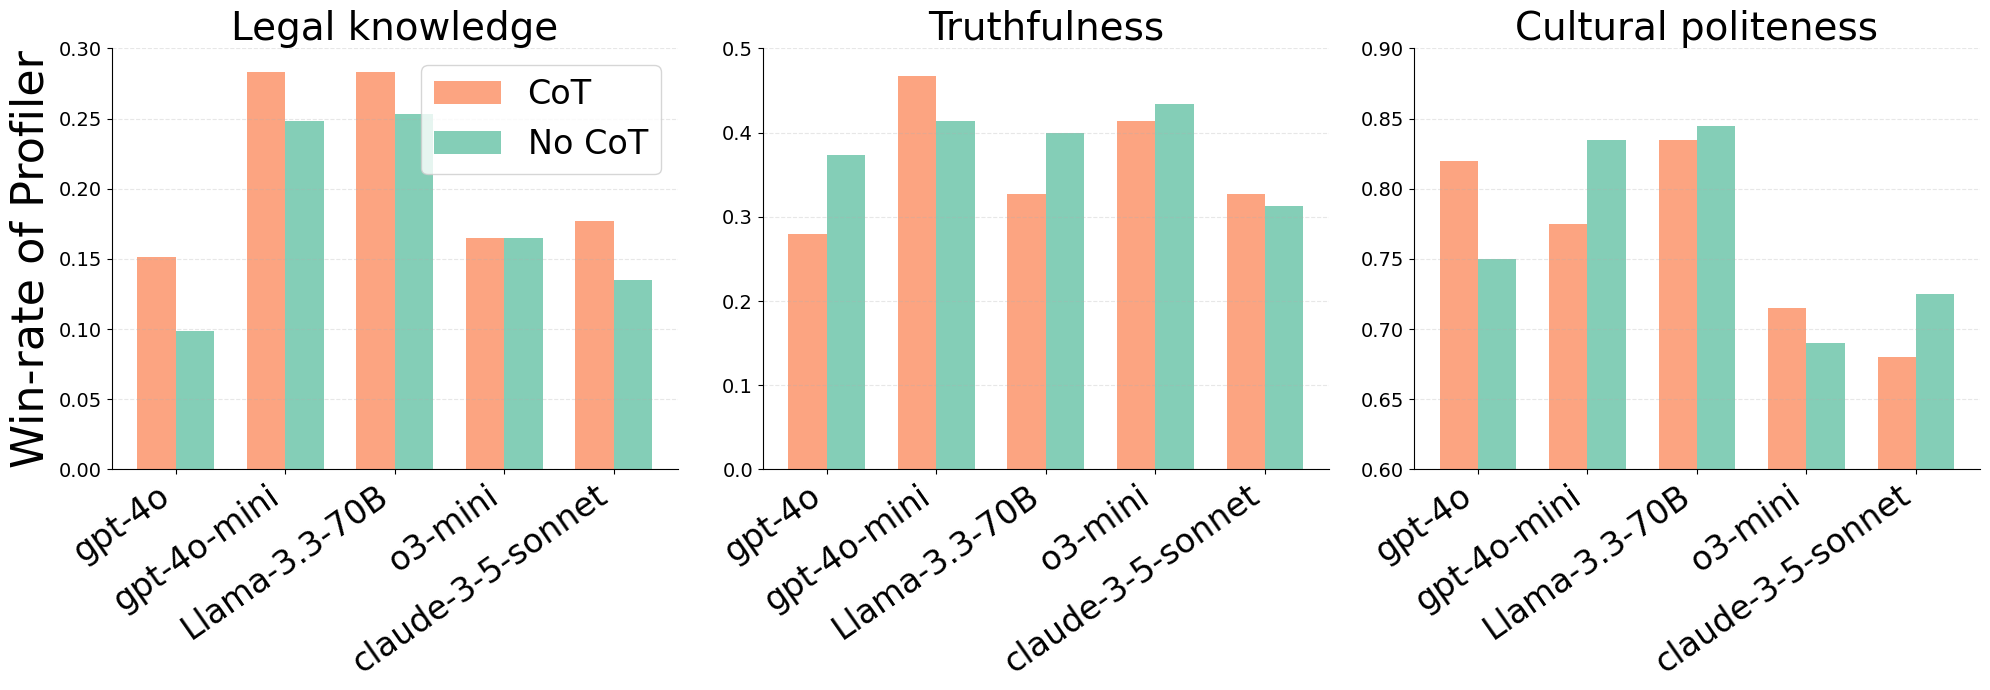

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a single figure with 3 subplots arranged horizontally, without shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(20, 7))  # Removed sharey=True

# Define colors using a Seaborn palette
palette = sns.color_palette("Set2", 2)
color_no_cot = palette[0]
color_cot = palette[1]

# Dictionary mapping dataset names to result dictionaries
dataset_results = {
    'Legal knowledge': aggregate_results_legal,
    'Truthfulness': tqa_result_dict,
    'Cultural politeness': politeness_result_dict,
}

# Dictionary for dataset-specific y-axis ranges
y_axis_ranges = {
    'Truthfulness': (0, 0.5),
    'Cultural politeness': (0.6, 0.9),
    'Legal knowledge': (0, 0.3)
}

# Width for bars
bar_width = 0.35

# Loop through the datasets and plot each on its own subplot
for i, (dataset_name, ax) in enumerate(zip(dataset_results.keys(), axes)):
    result_dict = dataset_results[dataset_name]
    
    # Reshape the data for plotting
    data = []
    for eval_model, generator_dict in result_dict.items():
        if 'openai/gpt-4o' in generator_dict:
            values = generator_dict['openai/gpt-4o']
            data.append({
                'Evaluated Model': eval_model.replace("-Instruct-Turbo", "").replace("-latest", ""),
                'Generator Model': 'openai/gpt-4o',
                'CoT': values.get('cot', 0),
                'No CoT': values.get('nocot', 0)
            })
    
    if not data:  # Skip if no data for this dataset
        ax.text(0.5, 0.5, f"No data found for dataset: {dataset_name}", 
                ha='center', va='center', fontsize=12)
        continue
    
    df_plot = pd.DataFrame(data)
    
    # Assign positions for each Evaluated Model
    eval_models = df_plot['Evaluated Model'].unique()
    x_pos = np.arange(len(eval_models))
    
    # Create the side-by-side bar plot
    cot_bars = ax.bar(x_pos - bar_width/2, df_plot['CoT'], bar_width, 
                      label='CoT' if i == 0 else None, color=color_cot, alpha=0.8)
    no_cot_bars = ax.bar(x_pos + bar_width/2, df_plot['No CoT'], bar_width, 
                         label='No CoT' if i == 0 else None, color=color_no_cot, alpha=0.8)
    
    # Set x-axis labels and ticks with shortened model names
    ax.set_xticks(x_pos)
    x_labels = [model.split('/')[-1] for model in eval_models]
    ax.set_xticklabels(x_labels, fontsize=24, rotation=35, ha='right')
    ax.tick_params(axis='y', labelsize=24)  # Make y ticks the same size as x ticks
    
    # Set dataset-specific y-axis range
    if dataset_name in y_axis_ranges:
        ax.set_ylim(y_axis_ranges[dataset_name])
    
    # Set titles for each subplot
    ax.set_title(f'{dataset_name}', fontsize=28)
    
    # Add grid for better readability (only horizontal grid lines)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Only add y-label to the first subplot
    if i == 0:
        ax.set_ylabel('Win-rate of Profiler', fontsize=32)
    
    # Make y-axis ticks larger
    ax.tick_params(axis='y', labelsize=14)
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add legend to the first subplot
axes[0].legend(fontsize=24, loc='upper right')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0.15)  # Slightly increased space between subplots for different y-axes
plt.savefig('ablations_pt1_4o.pdf', dpi=300)

## Heatmaps

heatmap_GPT_4o_legal_transfer_cot.pdf


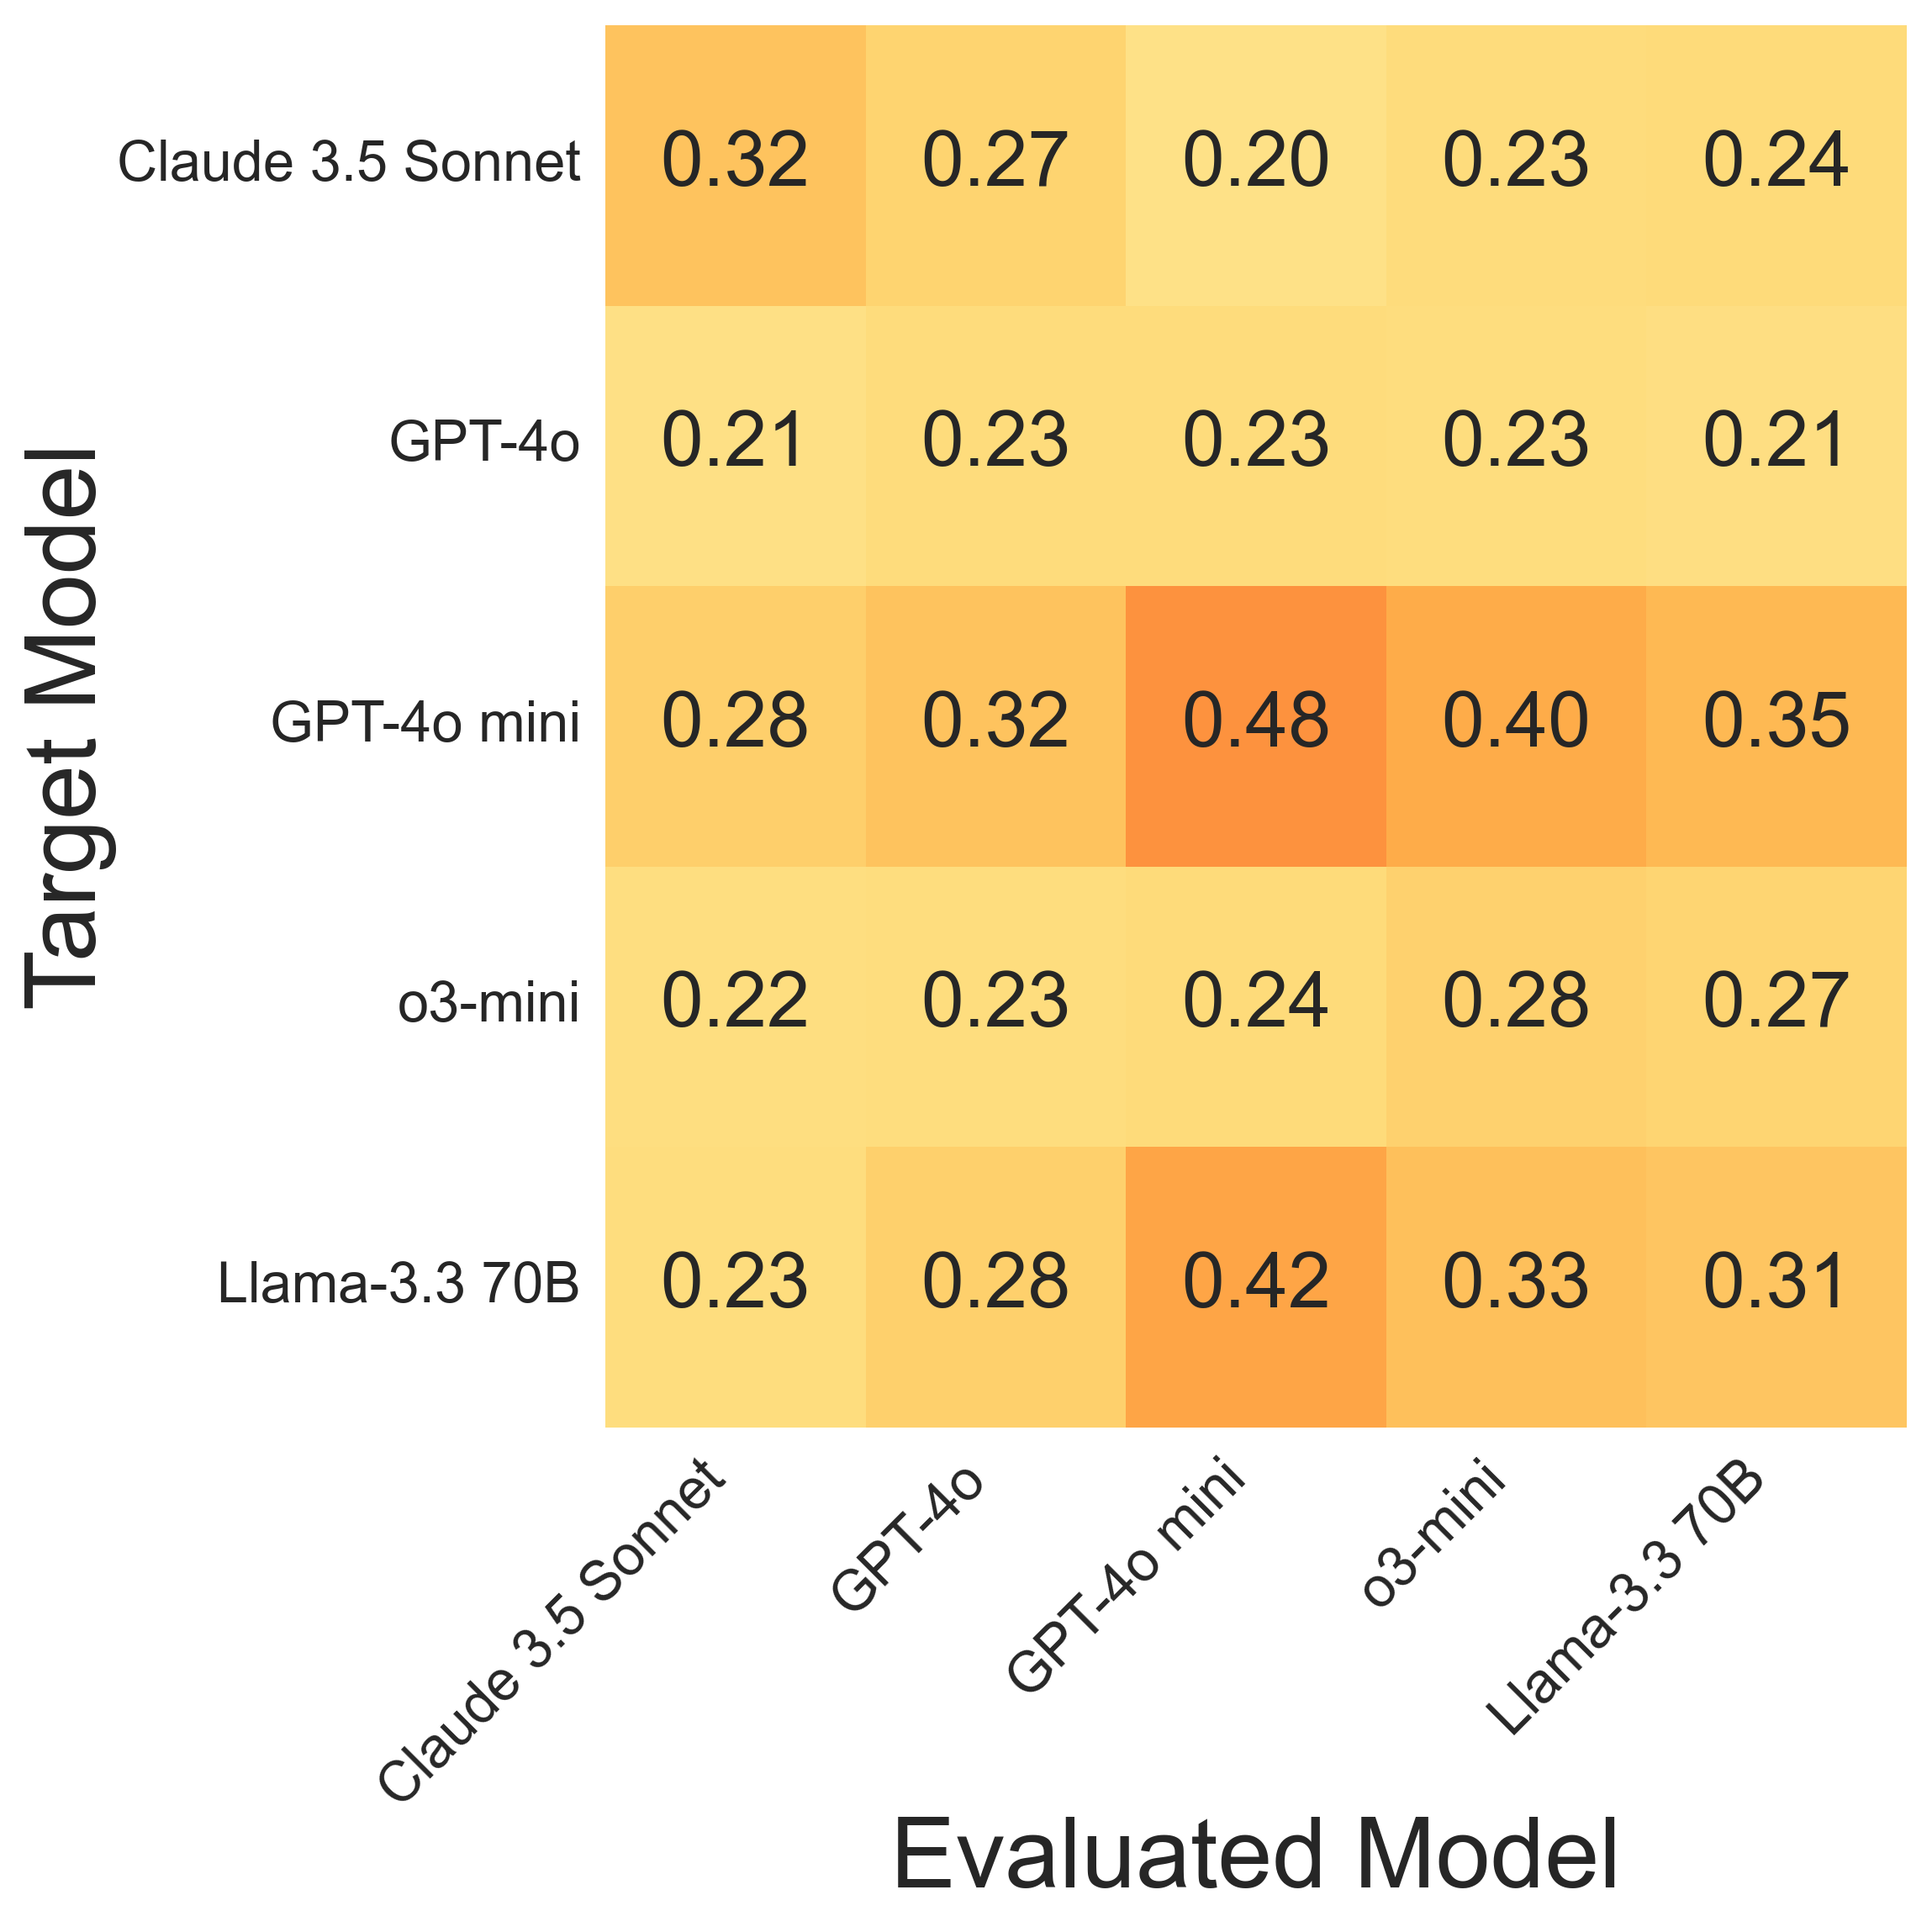

heatmap_o3_mini_legal_transfer_cot.pdf


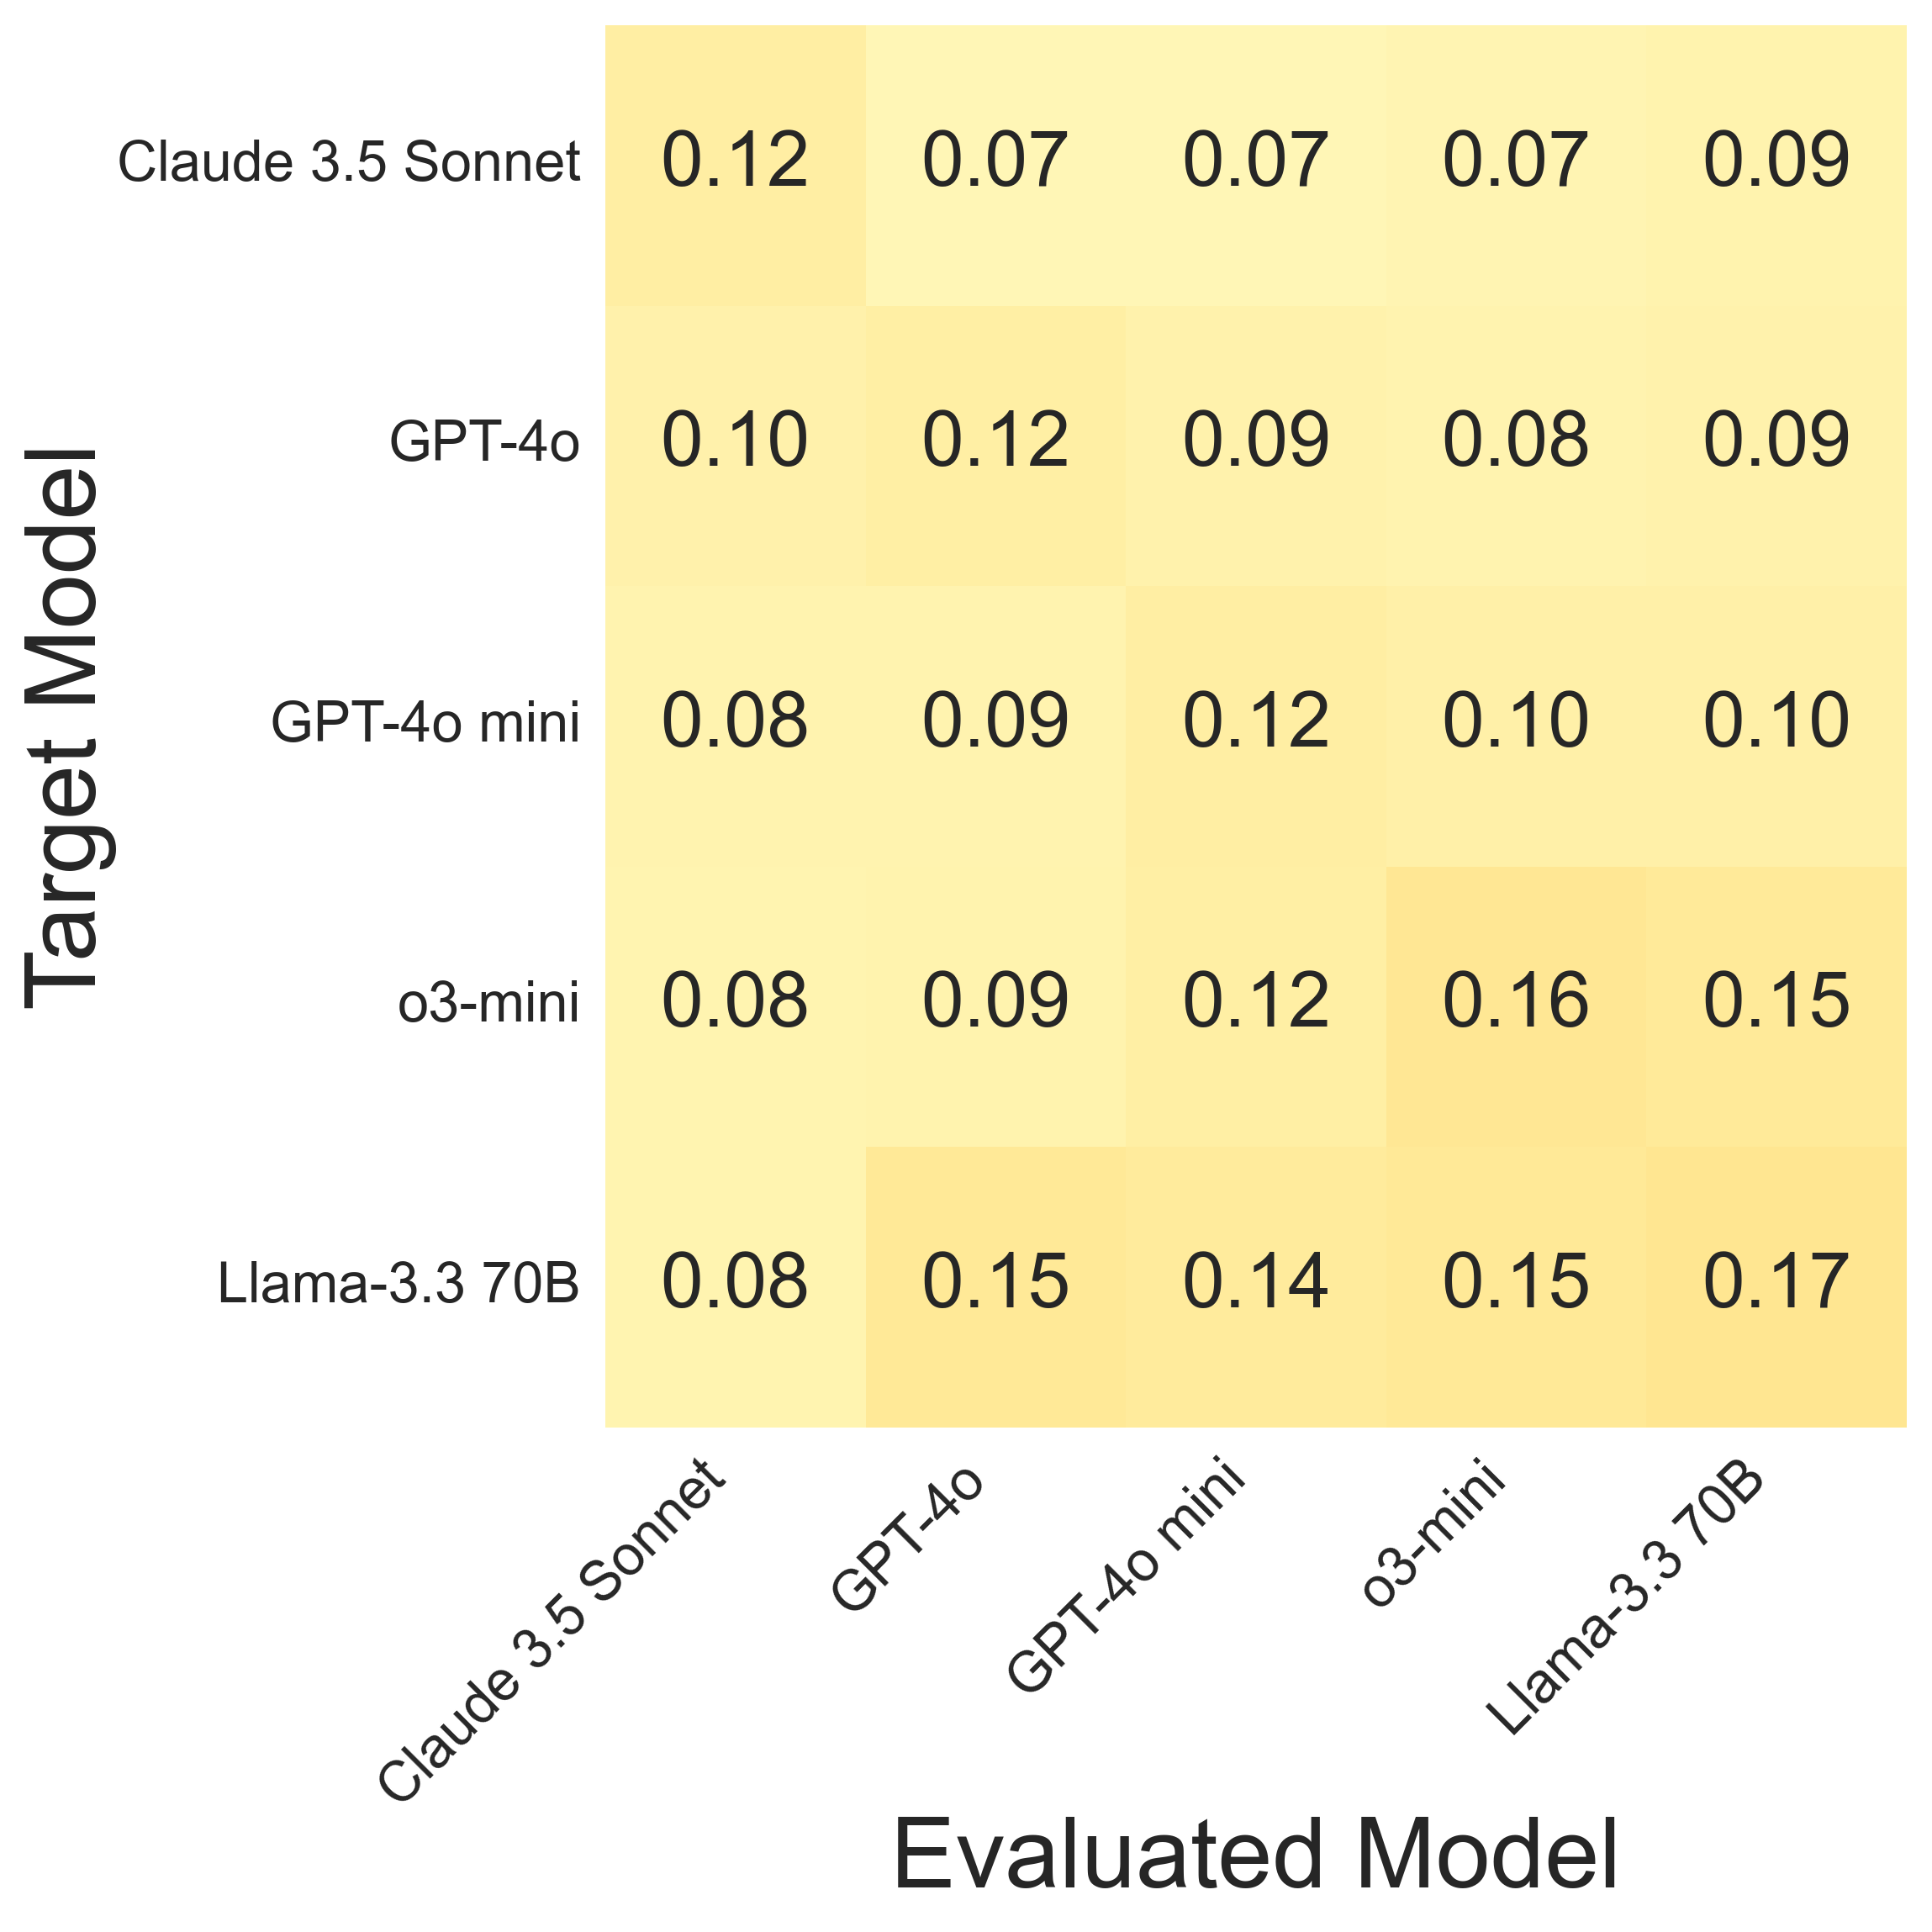

heatmap_GPT_4o_legal_transfer_nocot.pdf


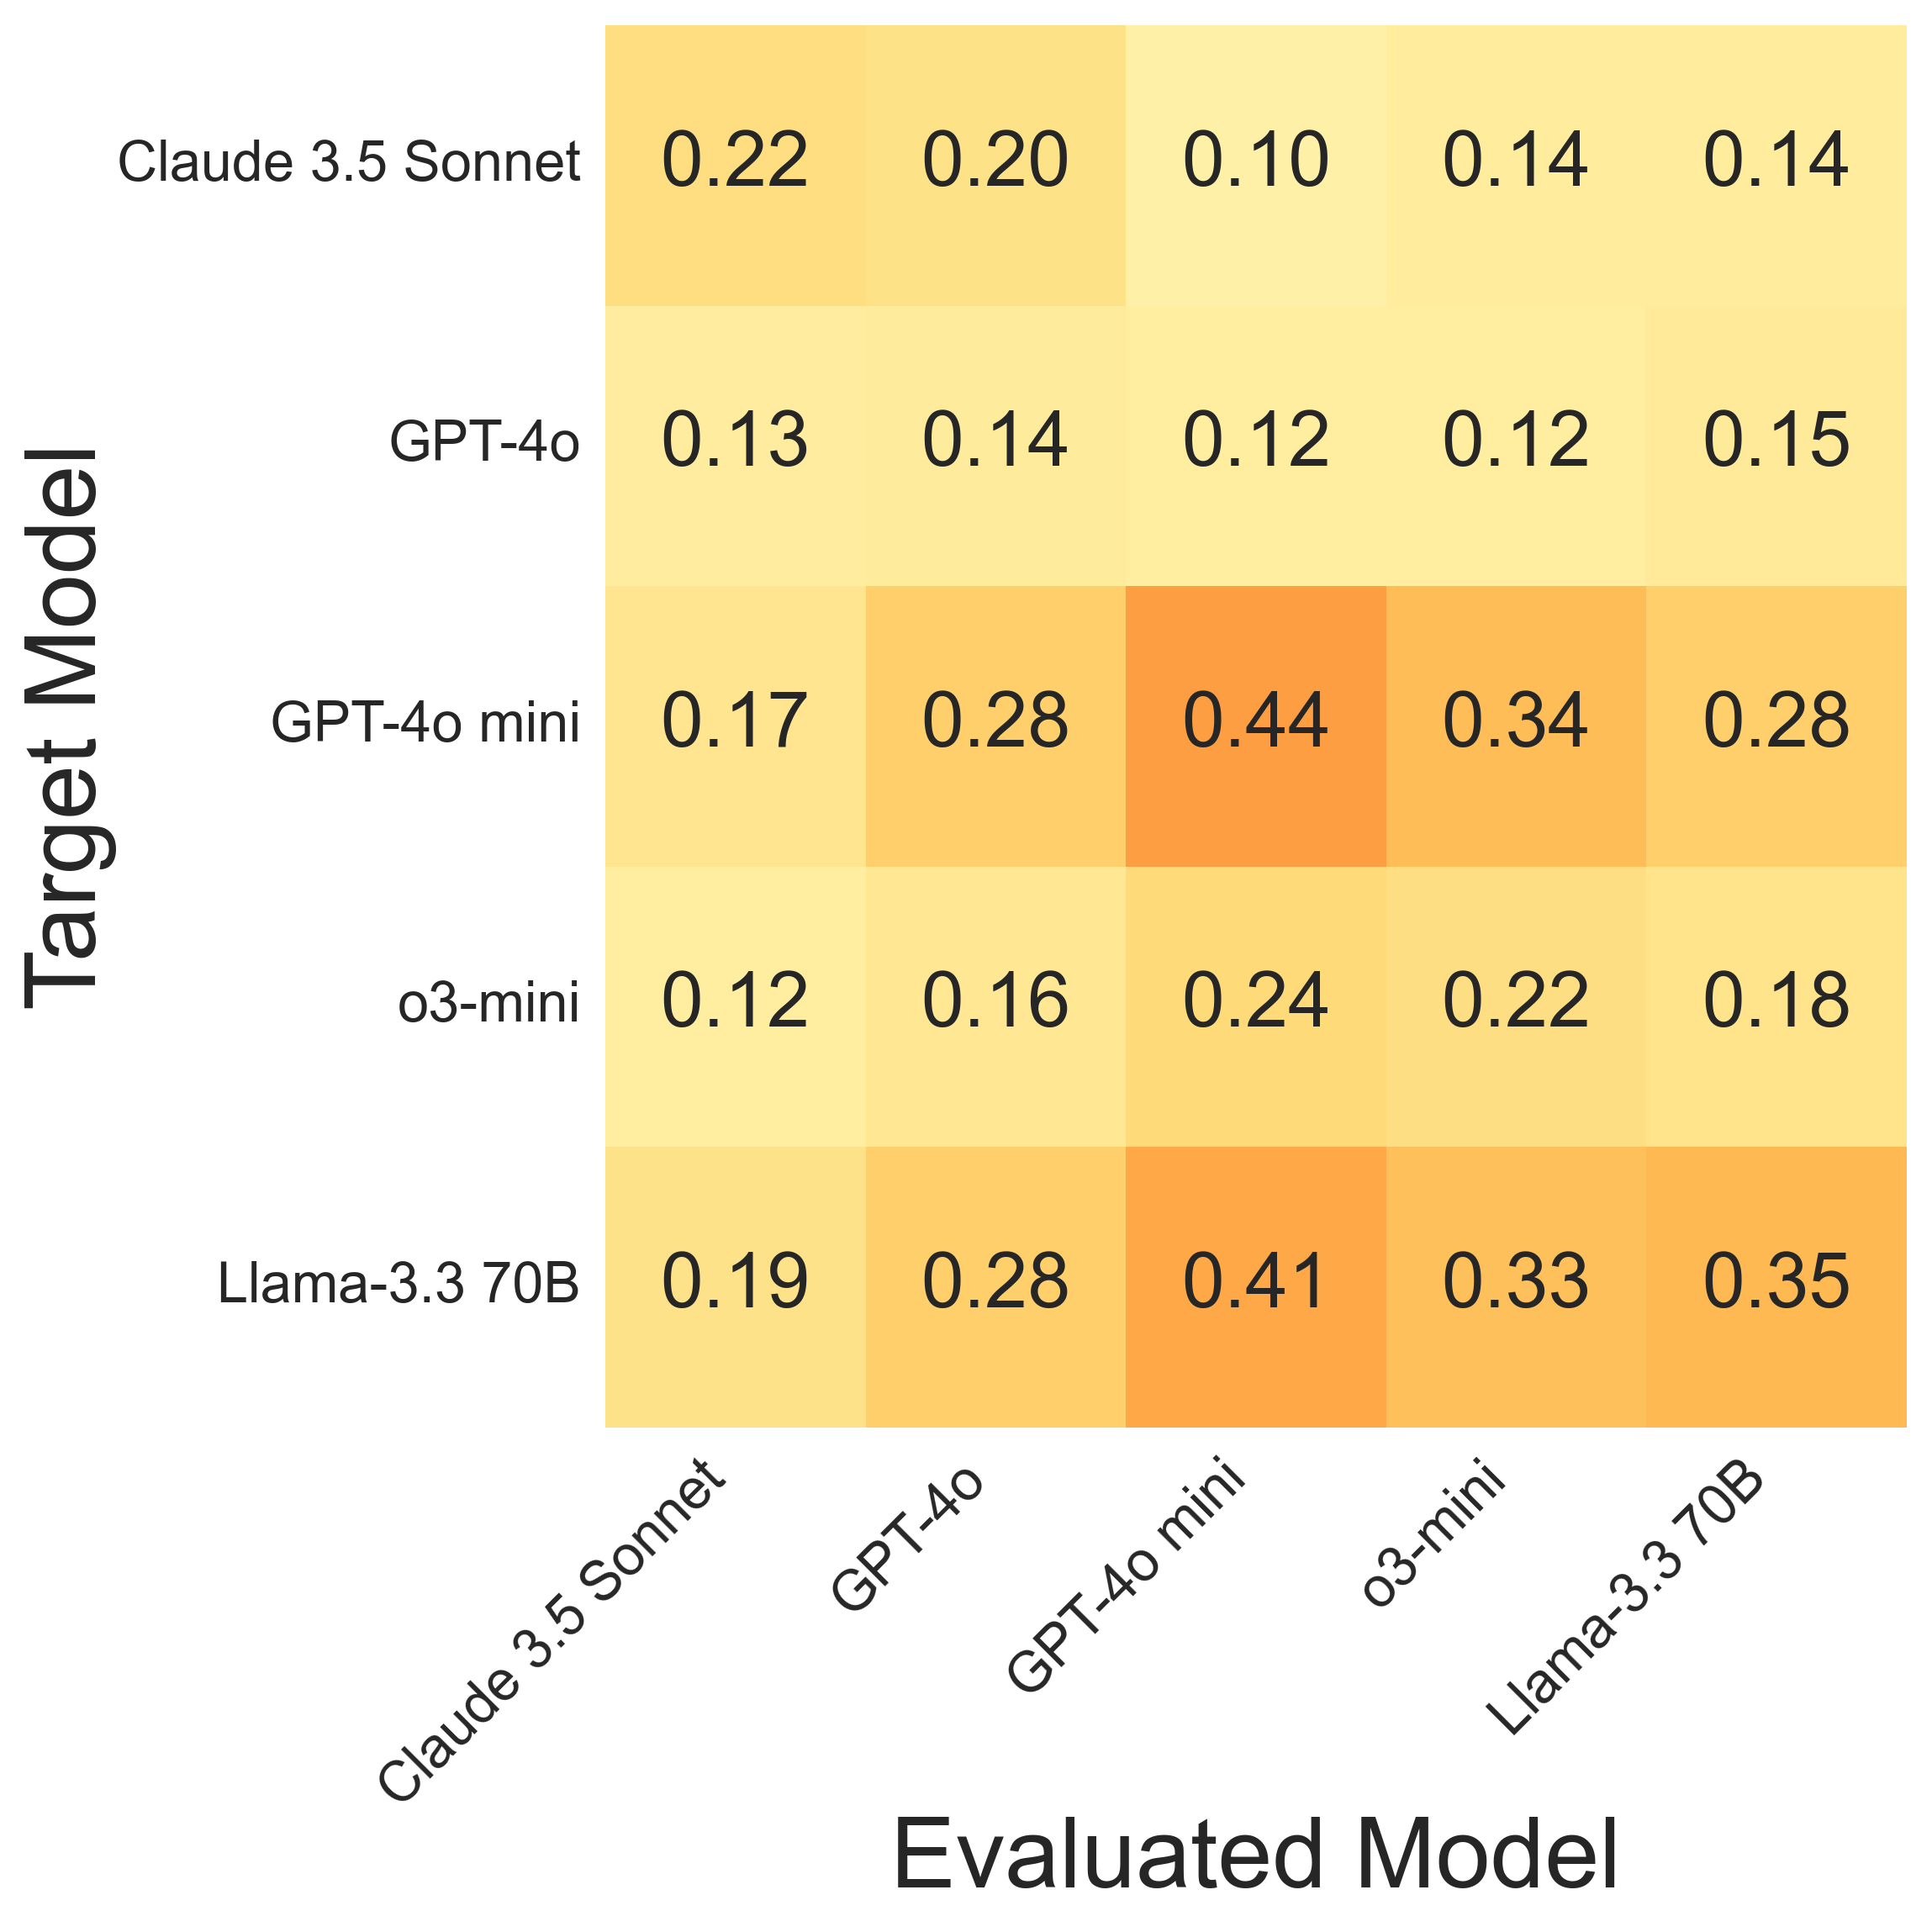

heatmap_o3_mini_legal_transfer_nocot.pdf


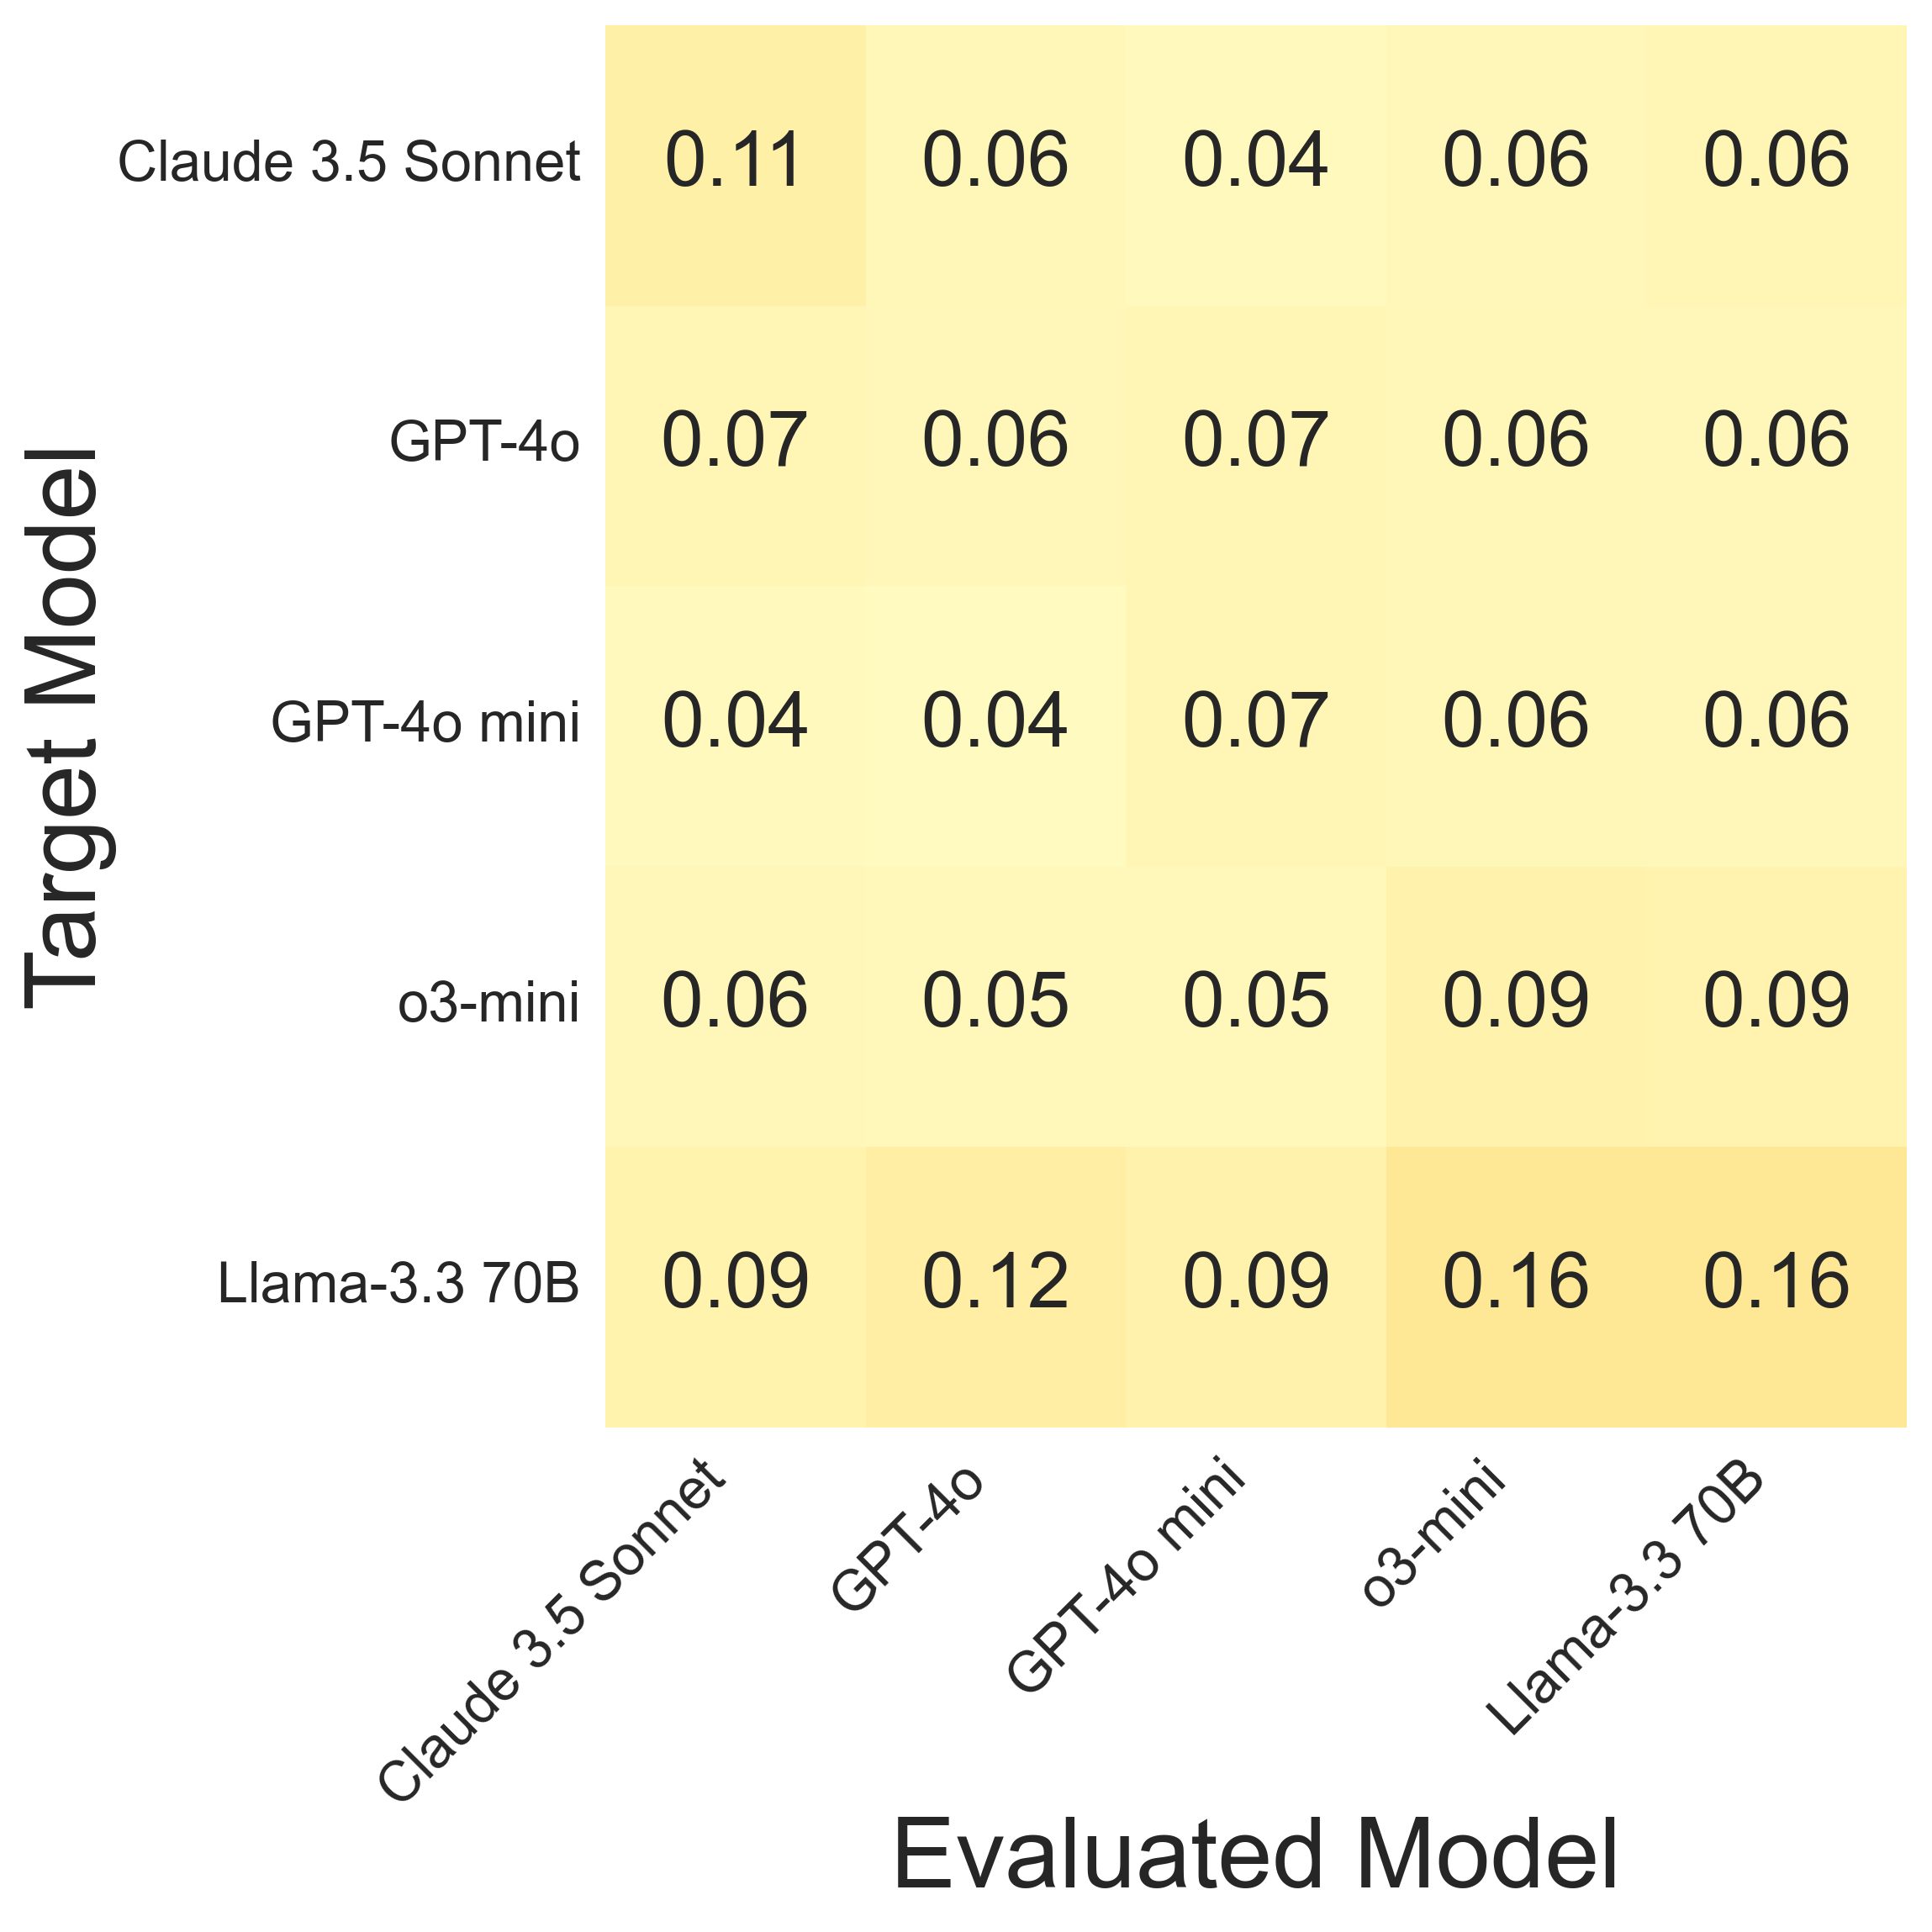

In [128]:
# Create heatmaps for each generator model - aggregate version only
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get unique generator models
for idx, df_legal in enumerate([df_cot_legal, df_nocot_legal]):
    generator_models = df_legal['generator_model_name'].unique()

    # Function to clean model names for better display
    def clean_model_name_for_display(name):
        return name.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B').replace('claude-3-5-sonnet-latest', 'Claude 3.5 Sonnet').replace('gpt-4o-mini', 'GPT-4o mini').replace('gpt-4o', 'GPT-4o').replace('openai/', '').replace('anthropic/', '').replace('-latest', '').replace('-Instruct-Turbo', '').replace('-latest', '').replace('together/meta-llama/', '')

    # Create a separate figure for each generator model
    for generator_model in generator_models:
        # Filter data for this generator model
        df_filtered = df_legal[df_legal['generator_model_name'] == generator_model]
        
        # Group by eval_model_name and re_eval_model_name and sum re_eval_incorrect_count
        # This aggregates across all tasks
        grouped_data = df_filtered.groupby(['eval_model_name', 're_eval_model_name']).agg({
            're_eval_incorrect_count': 'sum',
            'task_name': 'count'  # Count how many task entries we have for normalization
        }).reset_index()
        
        # Normalize by the total number of examples
        # Each task is out of 150 examples
        grouped_data['normalized_incorrect'] = grouped_data['re_eval_incorrect_count'] / 600
        
        # Create the pivot table using the normalized values
        try:
            heatmap_data = grouped_data.pivot(
                index='eval_model_name', 
                columns='re_eval_model_name', 
                values='normalized_incorrect'
            )
            
            # Clean up model names for better display
            heatmap_data.index = [clean_model_name_for_display(name) for name in heatmap_data.index]
            heatmap_data.columns = [clean_model_name_for_display(name) for name in heatmap_data.columns]
            
            sns.set_style("white")
            plt.rcParams.update({
                'font.size': 18,
                'axes.labelsize': 18,
                'axes.titlesize': 24,
                'xtick.labelsize': 18,
                'ytick.labelsize': 18
            })

            # Make the figure wide enough to avoid rotating x-axis labels
            plt.figure(figsize=(8, 8), dpi=300)

            
            # Create the heatmap
            ax = sns.heatmap(
                heatmap_data,
                annot=True,
                fmt='.2f',
                cmap='YlOrRd',
                cbar=False,
                square=False,  # Allow rectangular heatmap cells
                vmin=0,
                vmax=1,
                annot_kws={'size': 22}
            )
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Set title and labels
            # plt.title(f'Generator Model: {clean_model_name_for_display(generator_model)}', fontsize=24, pad=20)
            plt.xlabel('Evaluated Model', fontsize=28, labelpad=0)
            plt.ylabel('Target Model', fontsize=28, labelpad=0)
            
            # Increase tick label sizes
            plt.xticks(fontsize=16, rotation=45, ha='right')
            plt.yticks(fontsize=16)
            
            plt.tight_layout()
            plt.savefig(f'heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}_legal_transfer_{"cot" if idx == 0 else "nocot"}.pdf', dpi=300, bbox_inches='tight')
            print(f'heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}_legal_transfer_{"cot" if idx == 0 else "nocot"}.pdf')
            plt.show()
        except ValueError as e:
            print(f"Error creating heatmap for {generator_model}: {e}")
            
            # # If we hit the duplicate index error, we can try an alternative approach
            # # using pivot_table which can handle duplicates by applying an aggregation function
            # print(f"Trying alternative approach with pivot_table for {generator_model}")
            
            # heatmap_data = pd.pivot_table(
            #     grouped_data, 
            #     values='normalized_incorrect',
            #     index='eval_model_name',
            #     columns='re_eval_model_name',
            #     aggfunc='mean'  # Take the mean if there are duplicates
            # )
            
            # # Clean up model names for better display
            # heatmap_data.index = [clean_model_name_for_display(name) for name in heatmap_data.index]
            # heatmap_data.columns = [clean_model_name_for_display(name) for name in heatmap_data.columns]
            
            # # Create the figure
            # plt.figure(figsize=(14, 12))
            
            # # Create the heatmap
            # ax = sns.heatmap(
            #     heatmap_data,
            #     annot=True,
            #     fmt='.2f',
            #     cmap='YlOrRd',
            #     cbar=False,
            #     square=False,
            #     vmin=0,
            #     vmax=1,
            #     annot_kws={'size': 22}
            # )
            
            # # Remove top and right spines
            # ax.spines['top'].set_visible(False)
            # ax.spines['right'].set_visible(False)
            
            # # Set title and labels
            # # plt.title(f'Generator Model: {clean_model_name_for_display(generator_model)}', fontsize=24, pad=20)
            # plt.xlabel('Evaluated Model', fontsize=28, labelpad=15)
            # plt.ylabel('Target Model', fontsize=28, labelpad=15)
            
            # # Increase tick label sizes
            # plt.xticks(fontsize=16, rotation=45, ha='right')
            # plt.yticks(fontsize=16)
            
            # plt.tight_layout()
            # plt.savefig(f'heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}_legal_transfer_{"cot" if idx == 0 else "nocot"}.pdf', dpi=300, bbox_inches='tight')
            # # plt.show()
            # print(f'heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}_legal_transfer_{"cot" if idx == 0 else "nocot"}.pdf')

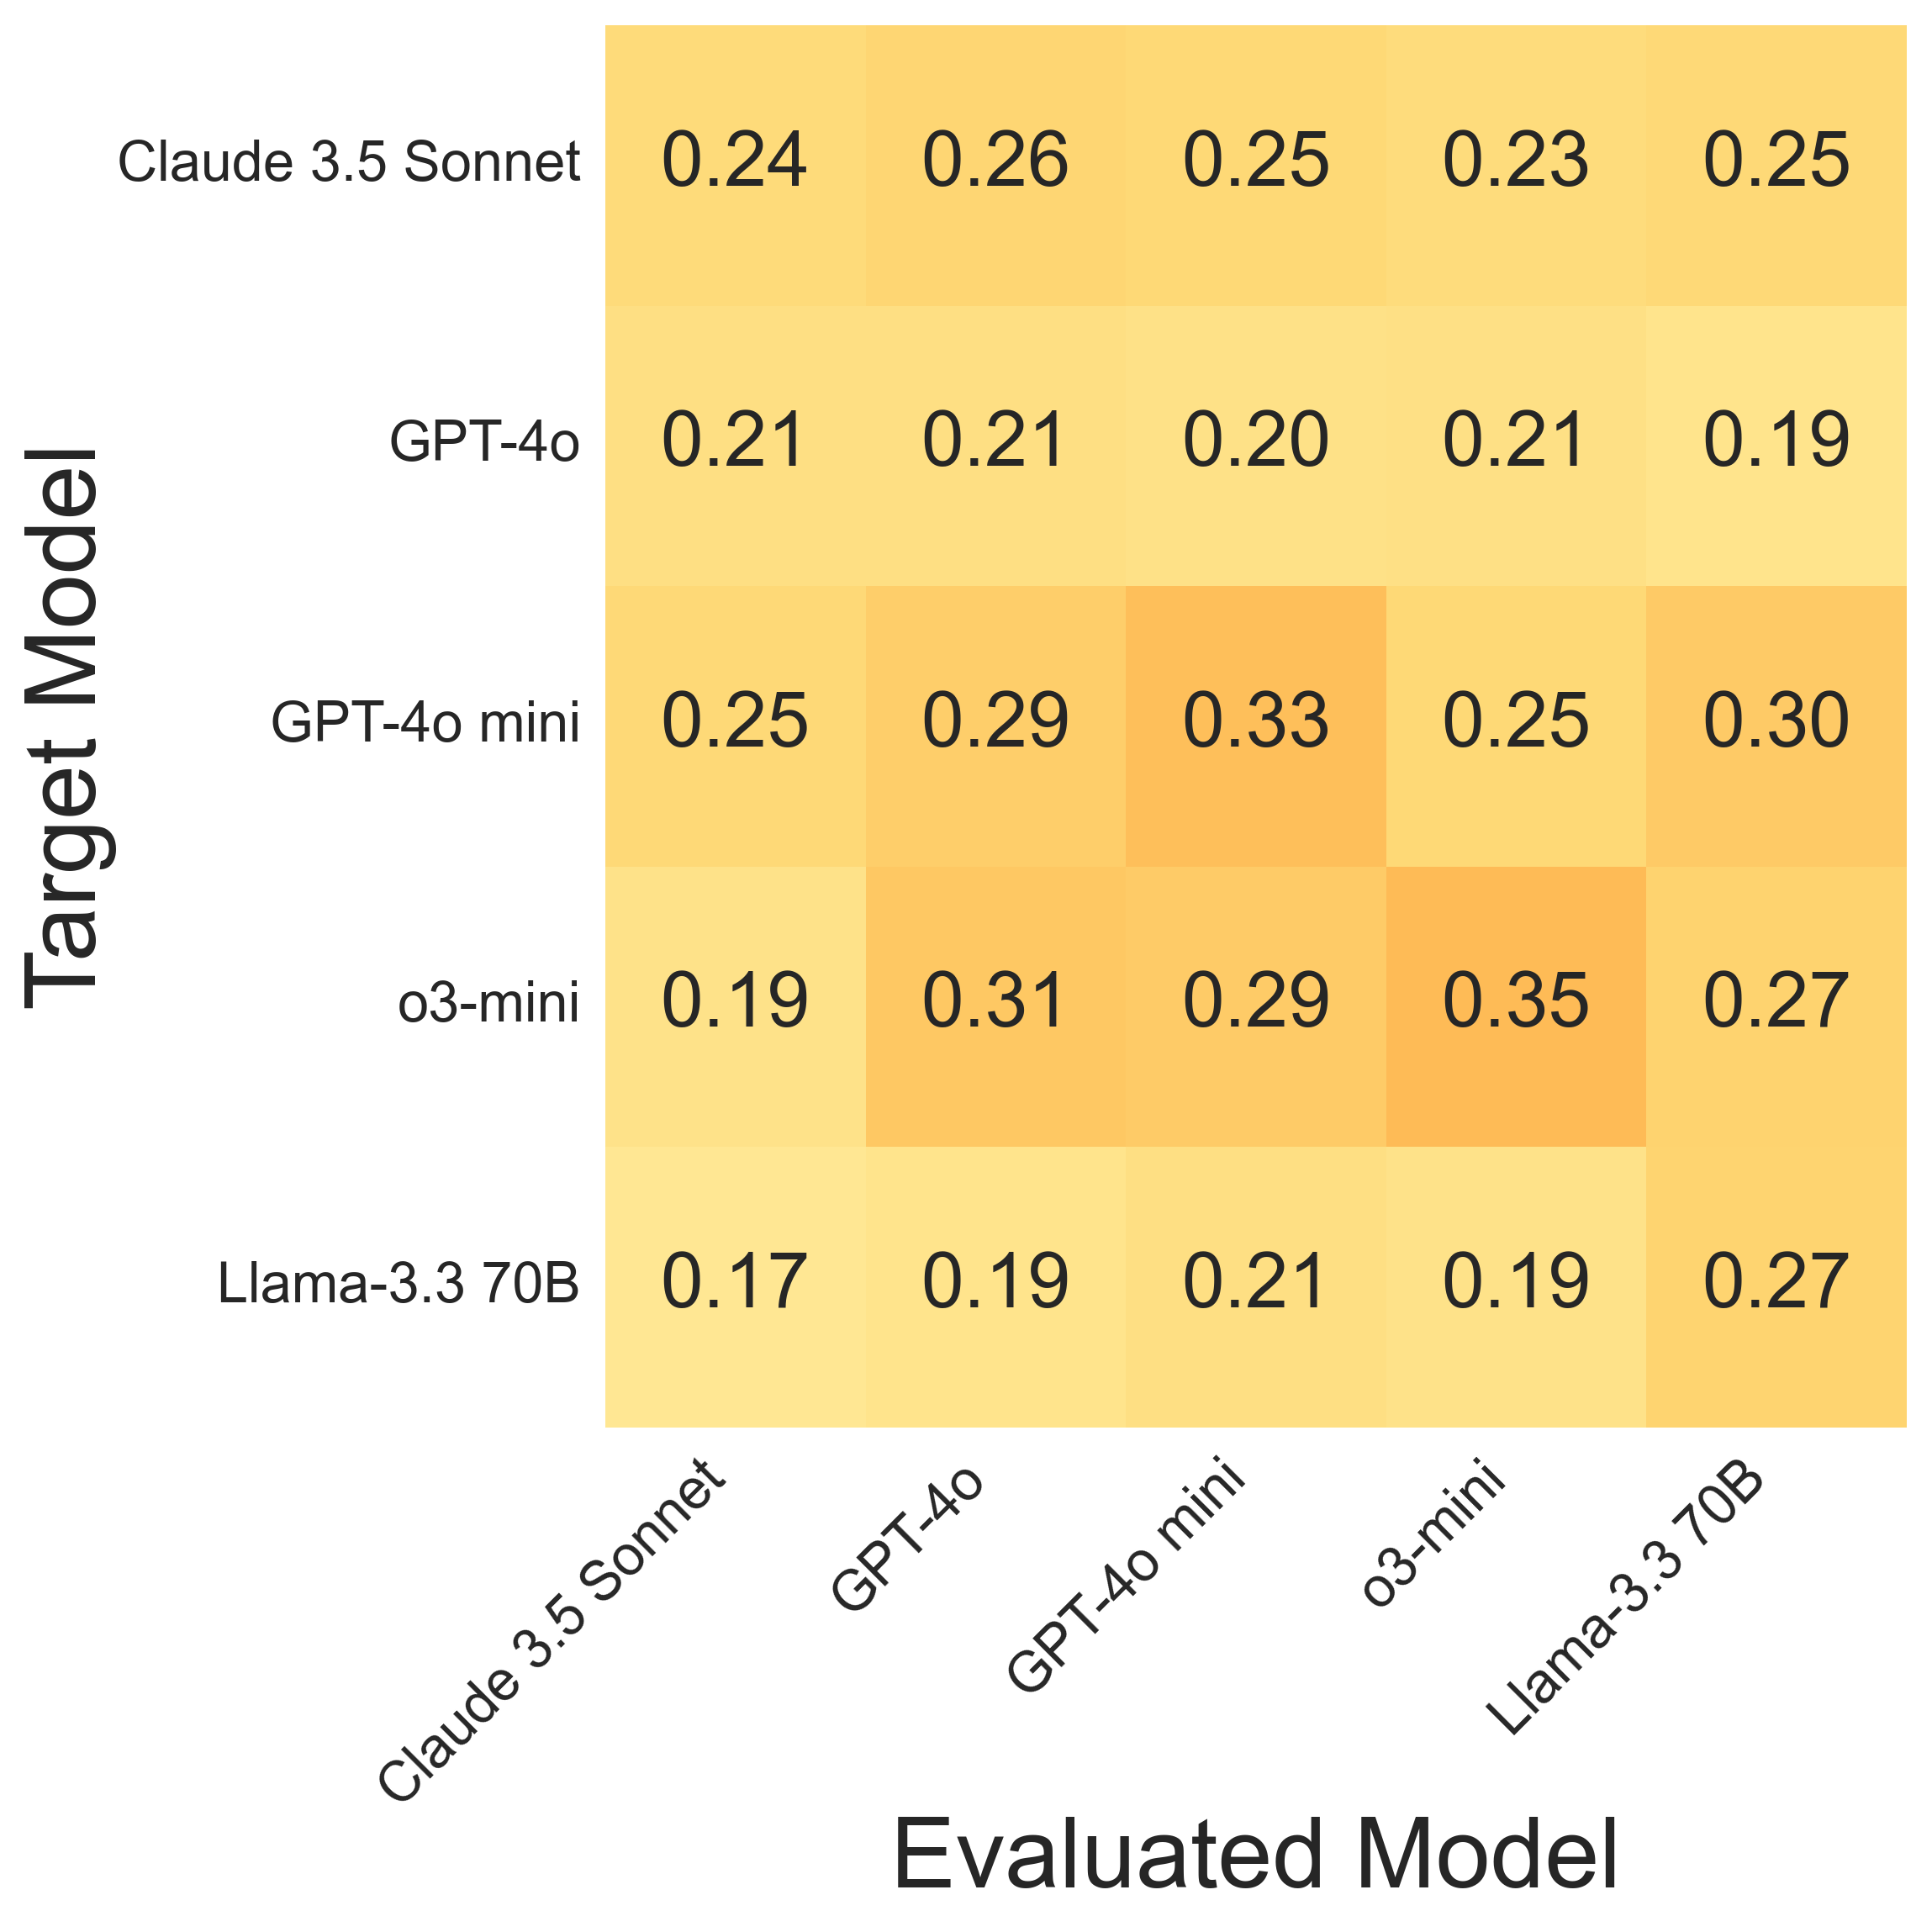

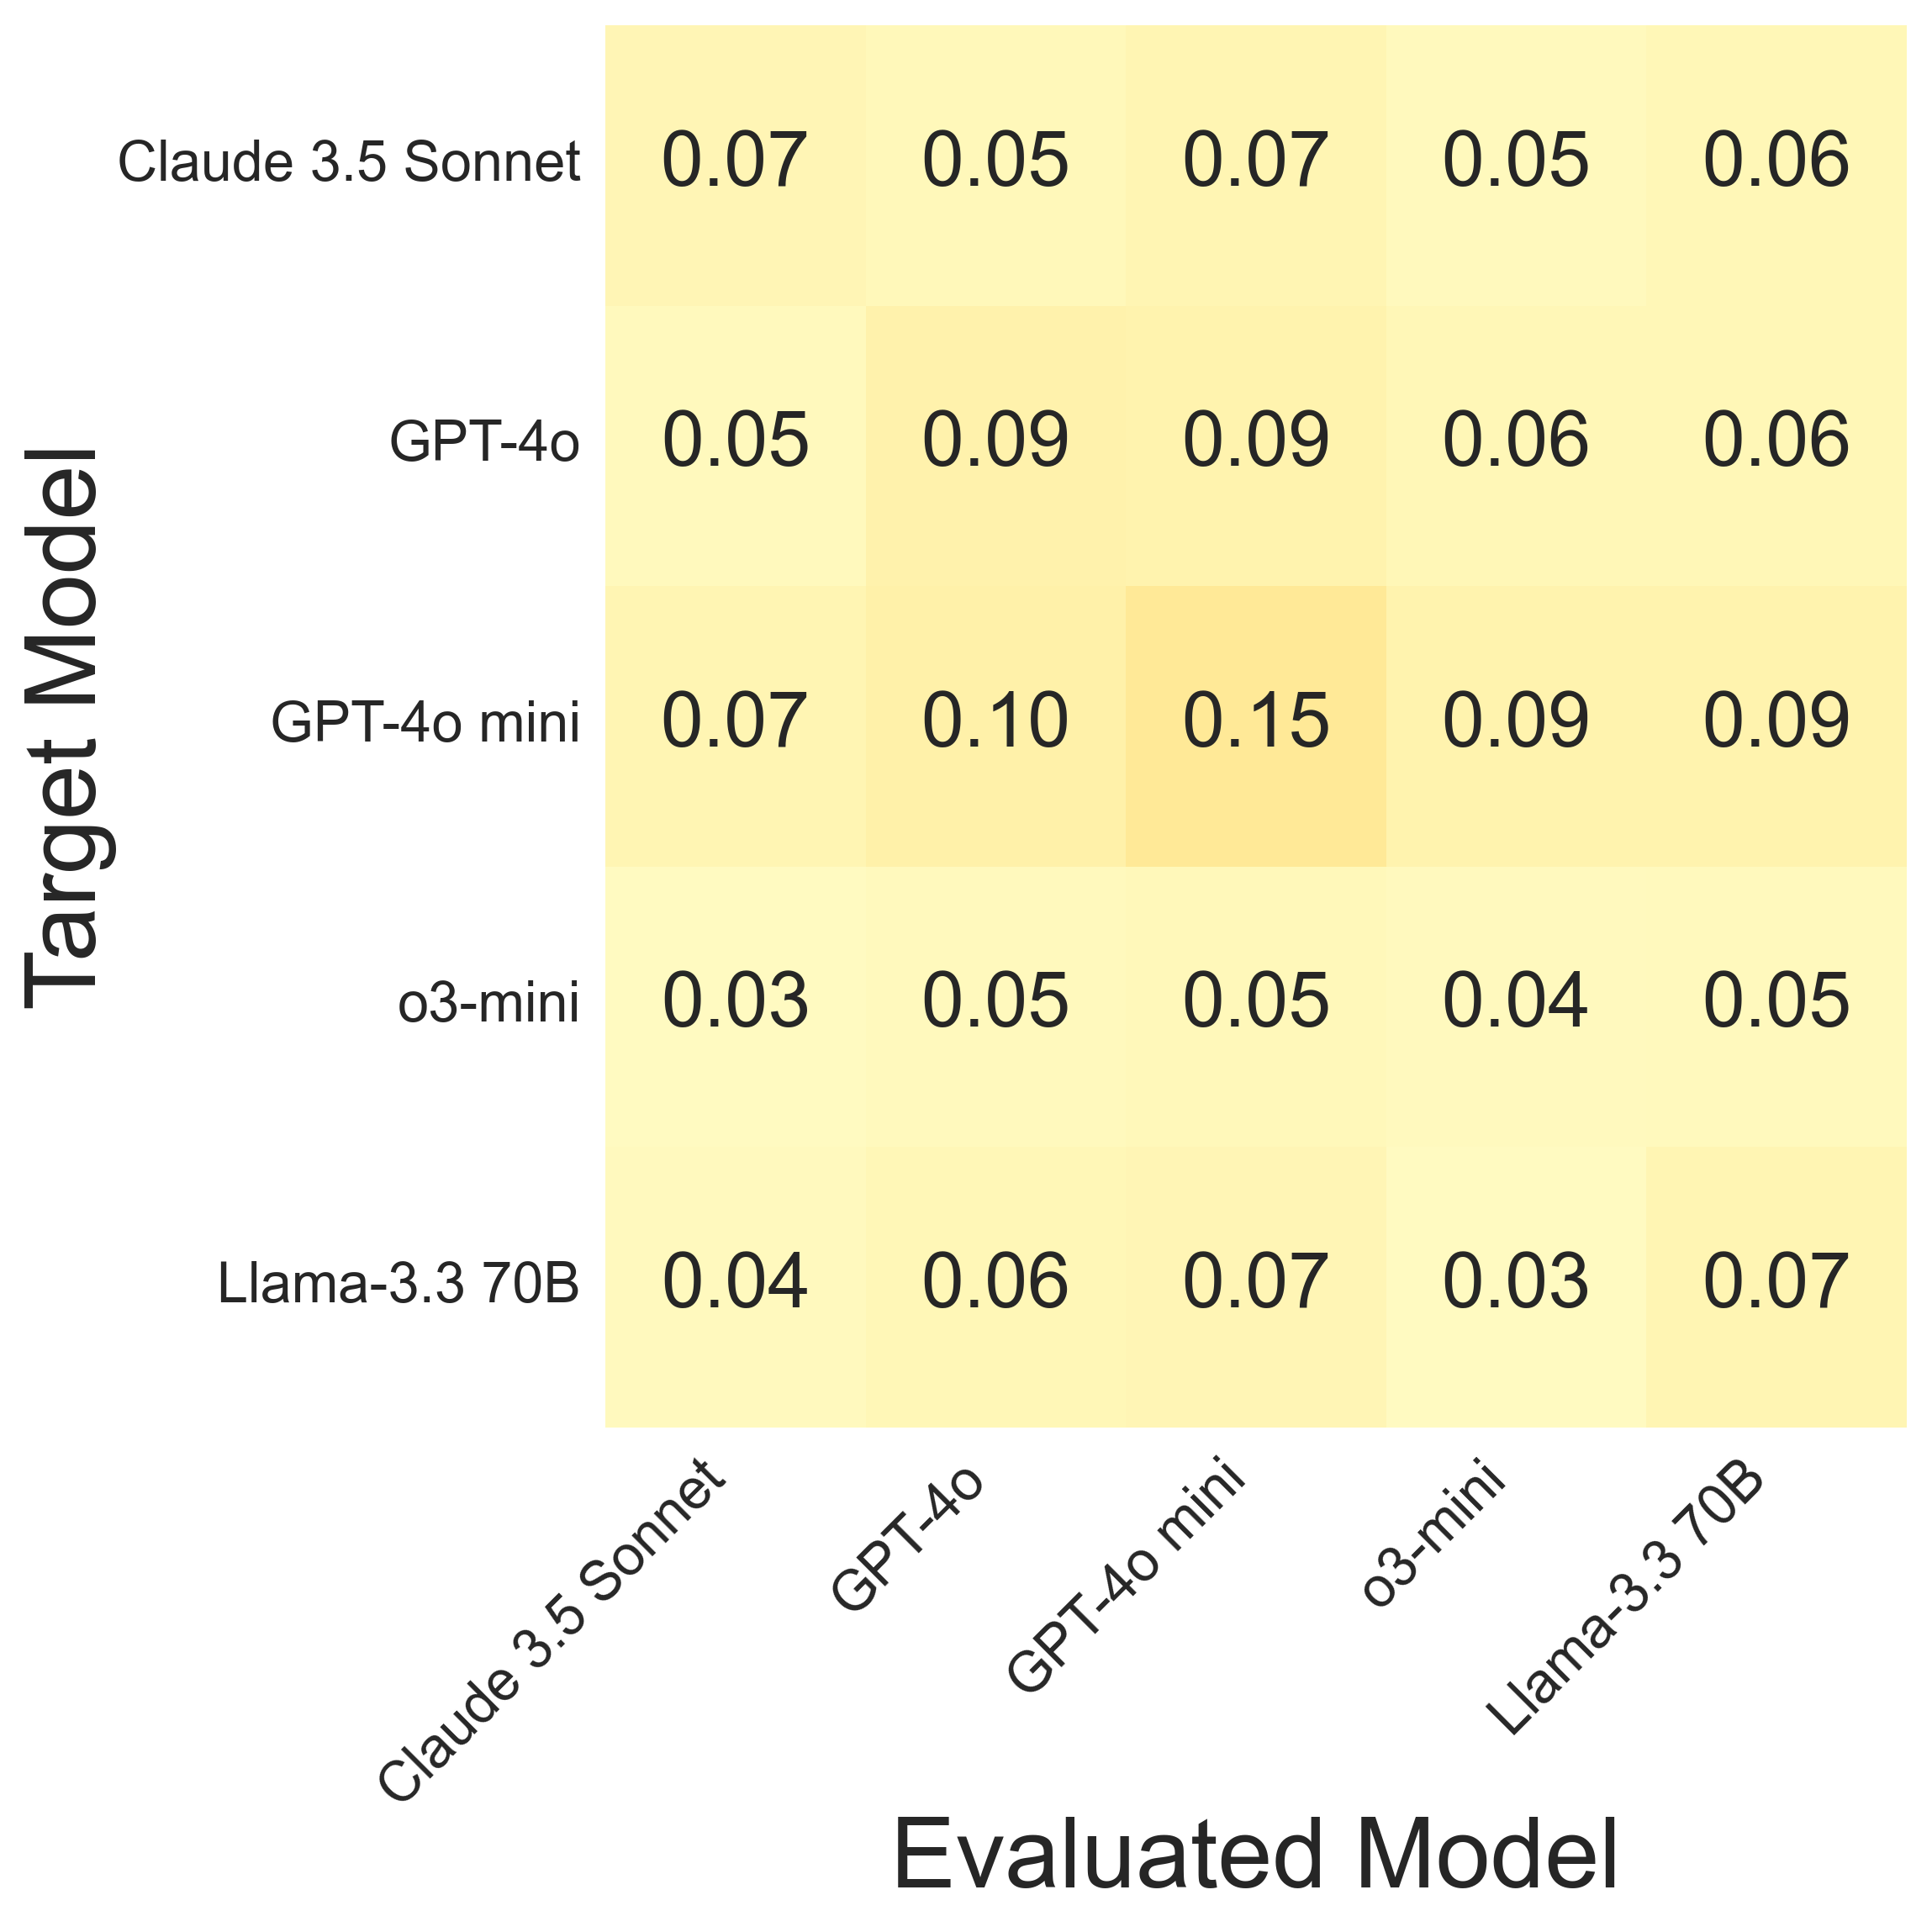

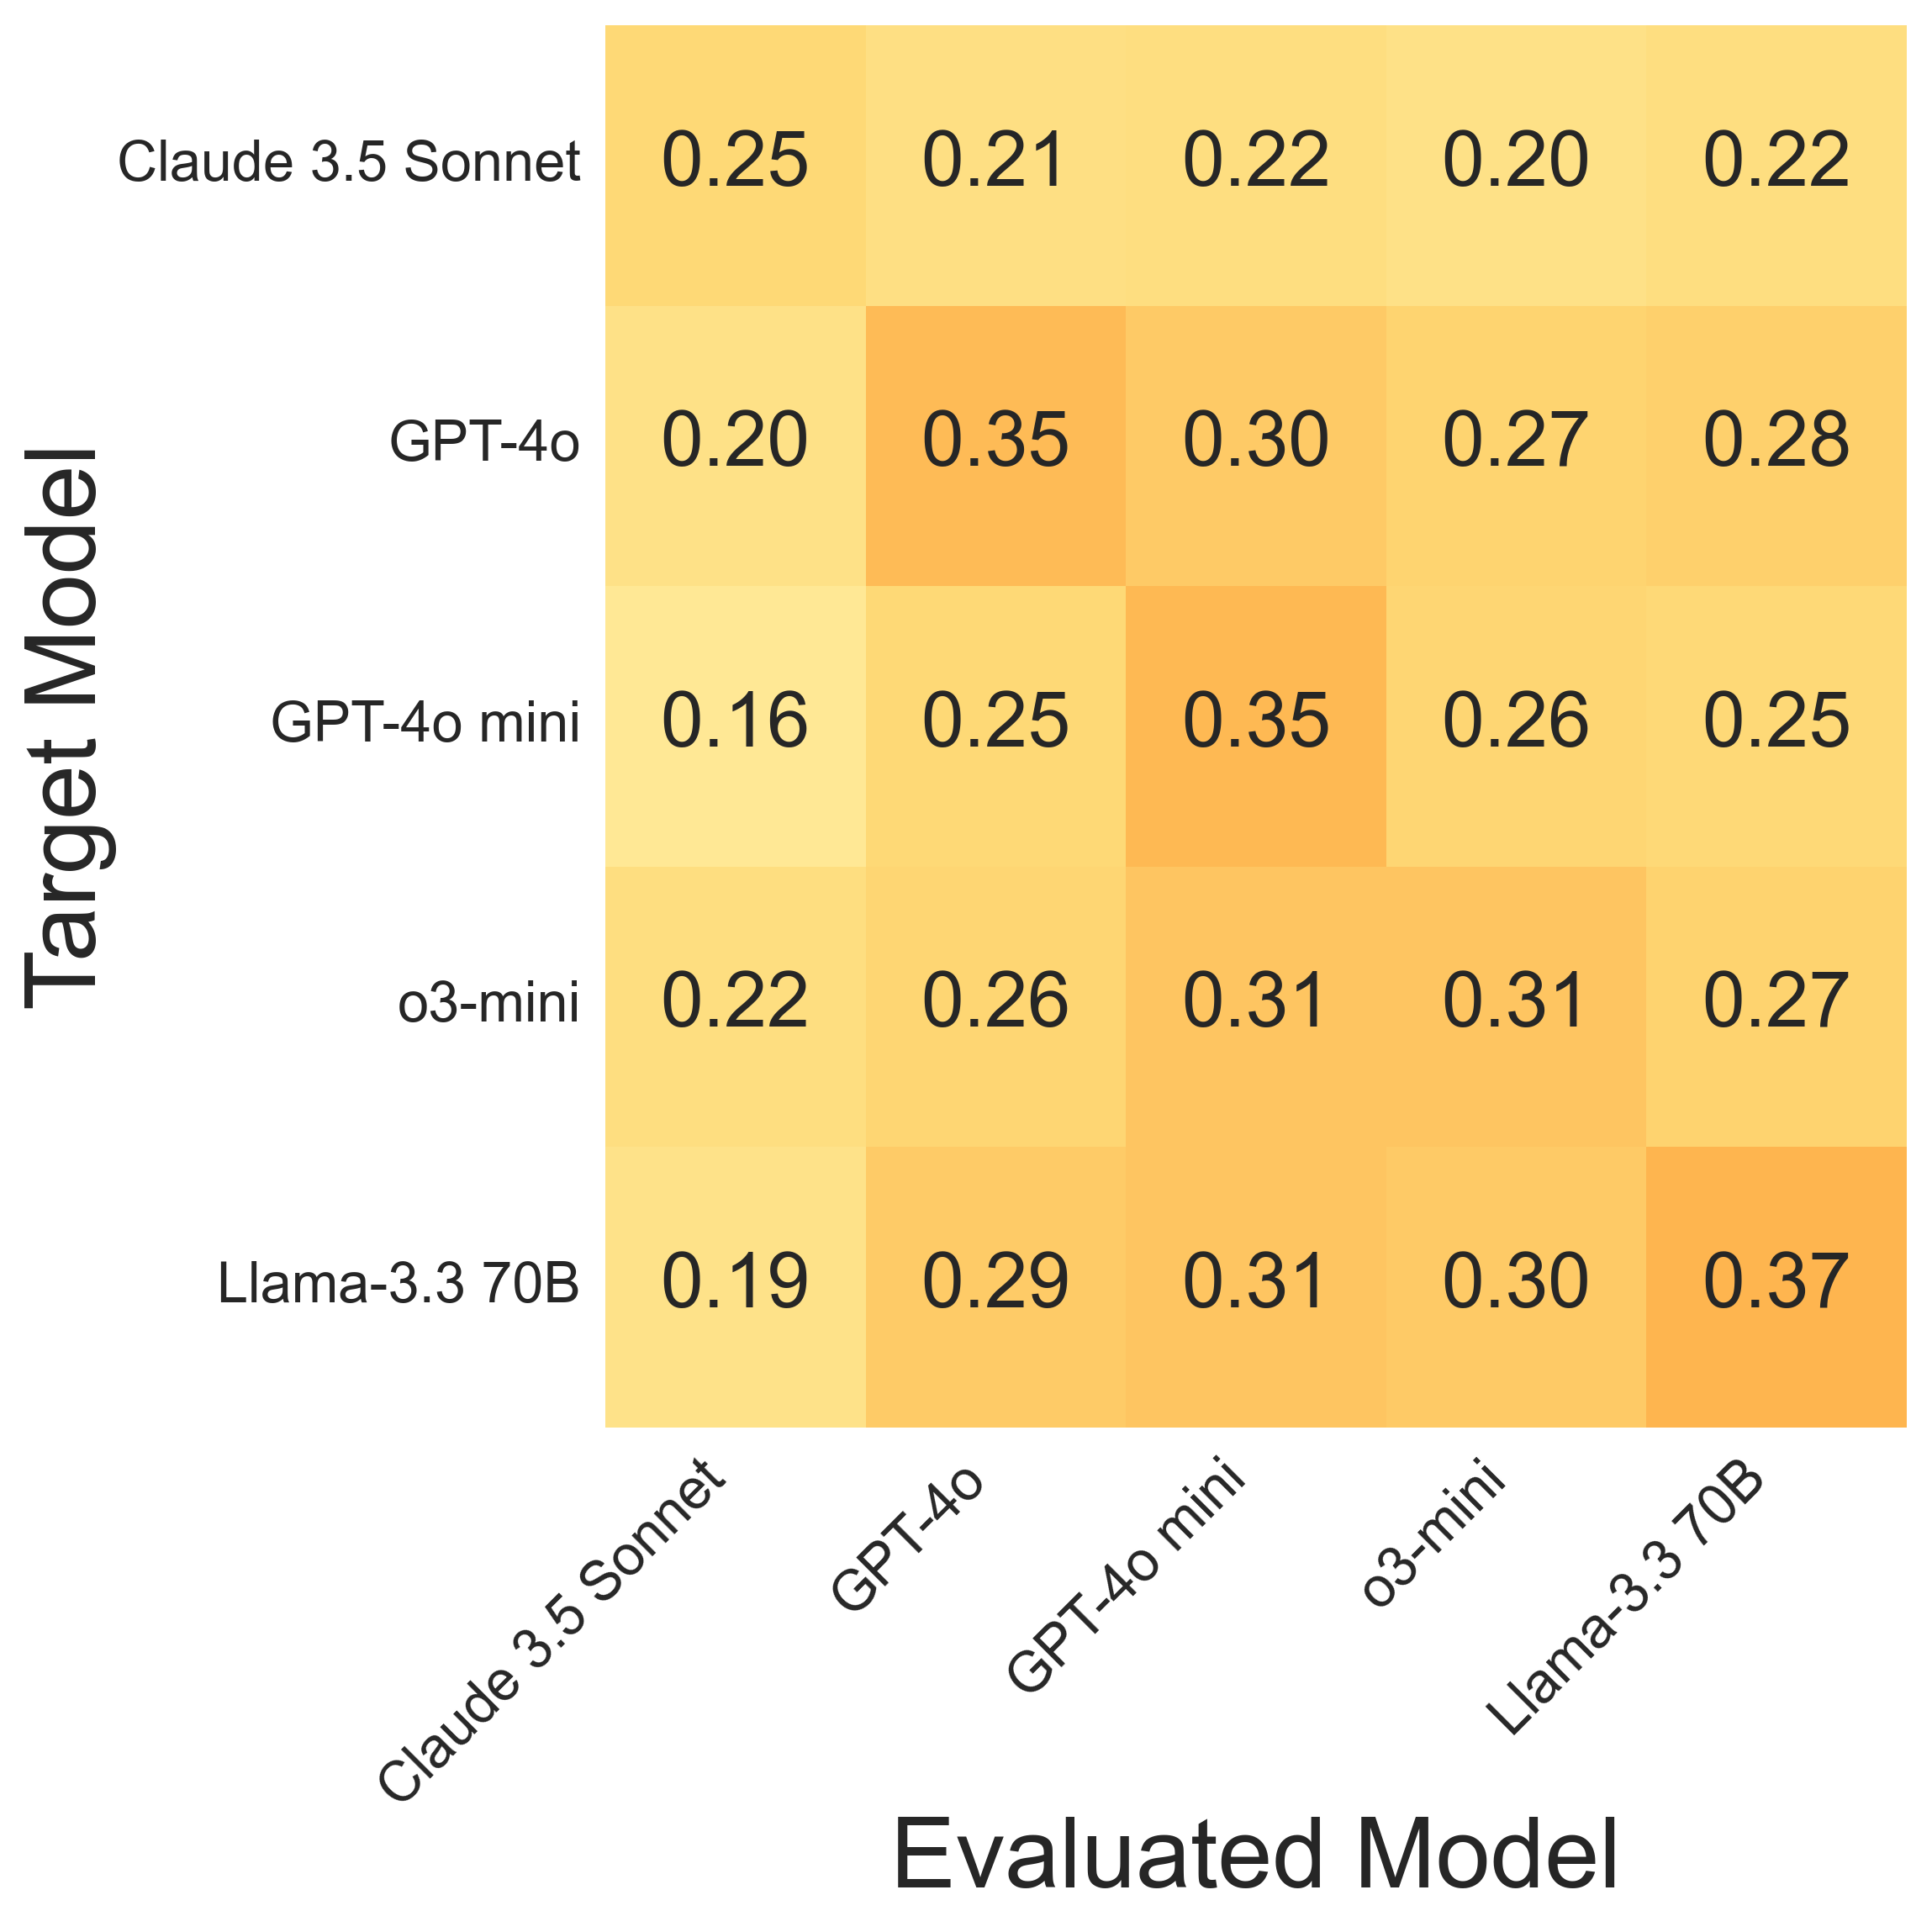

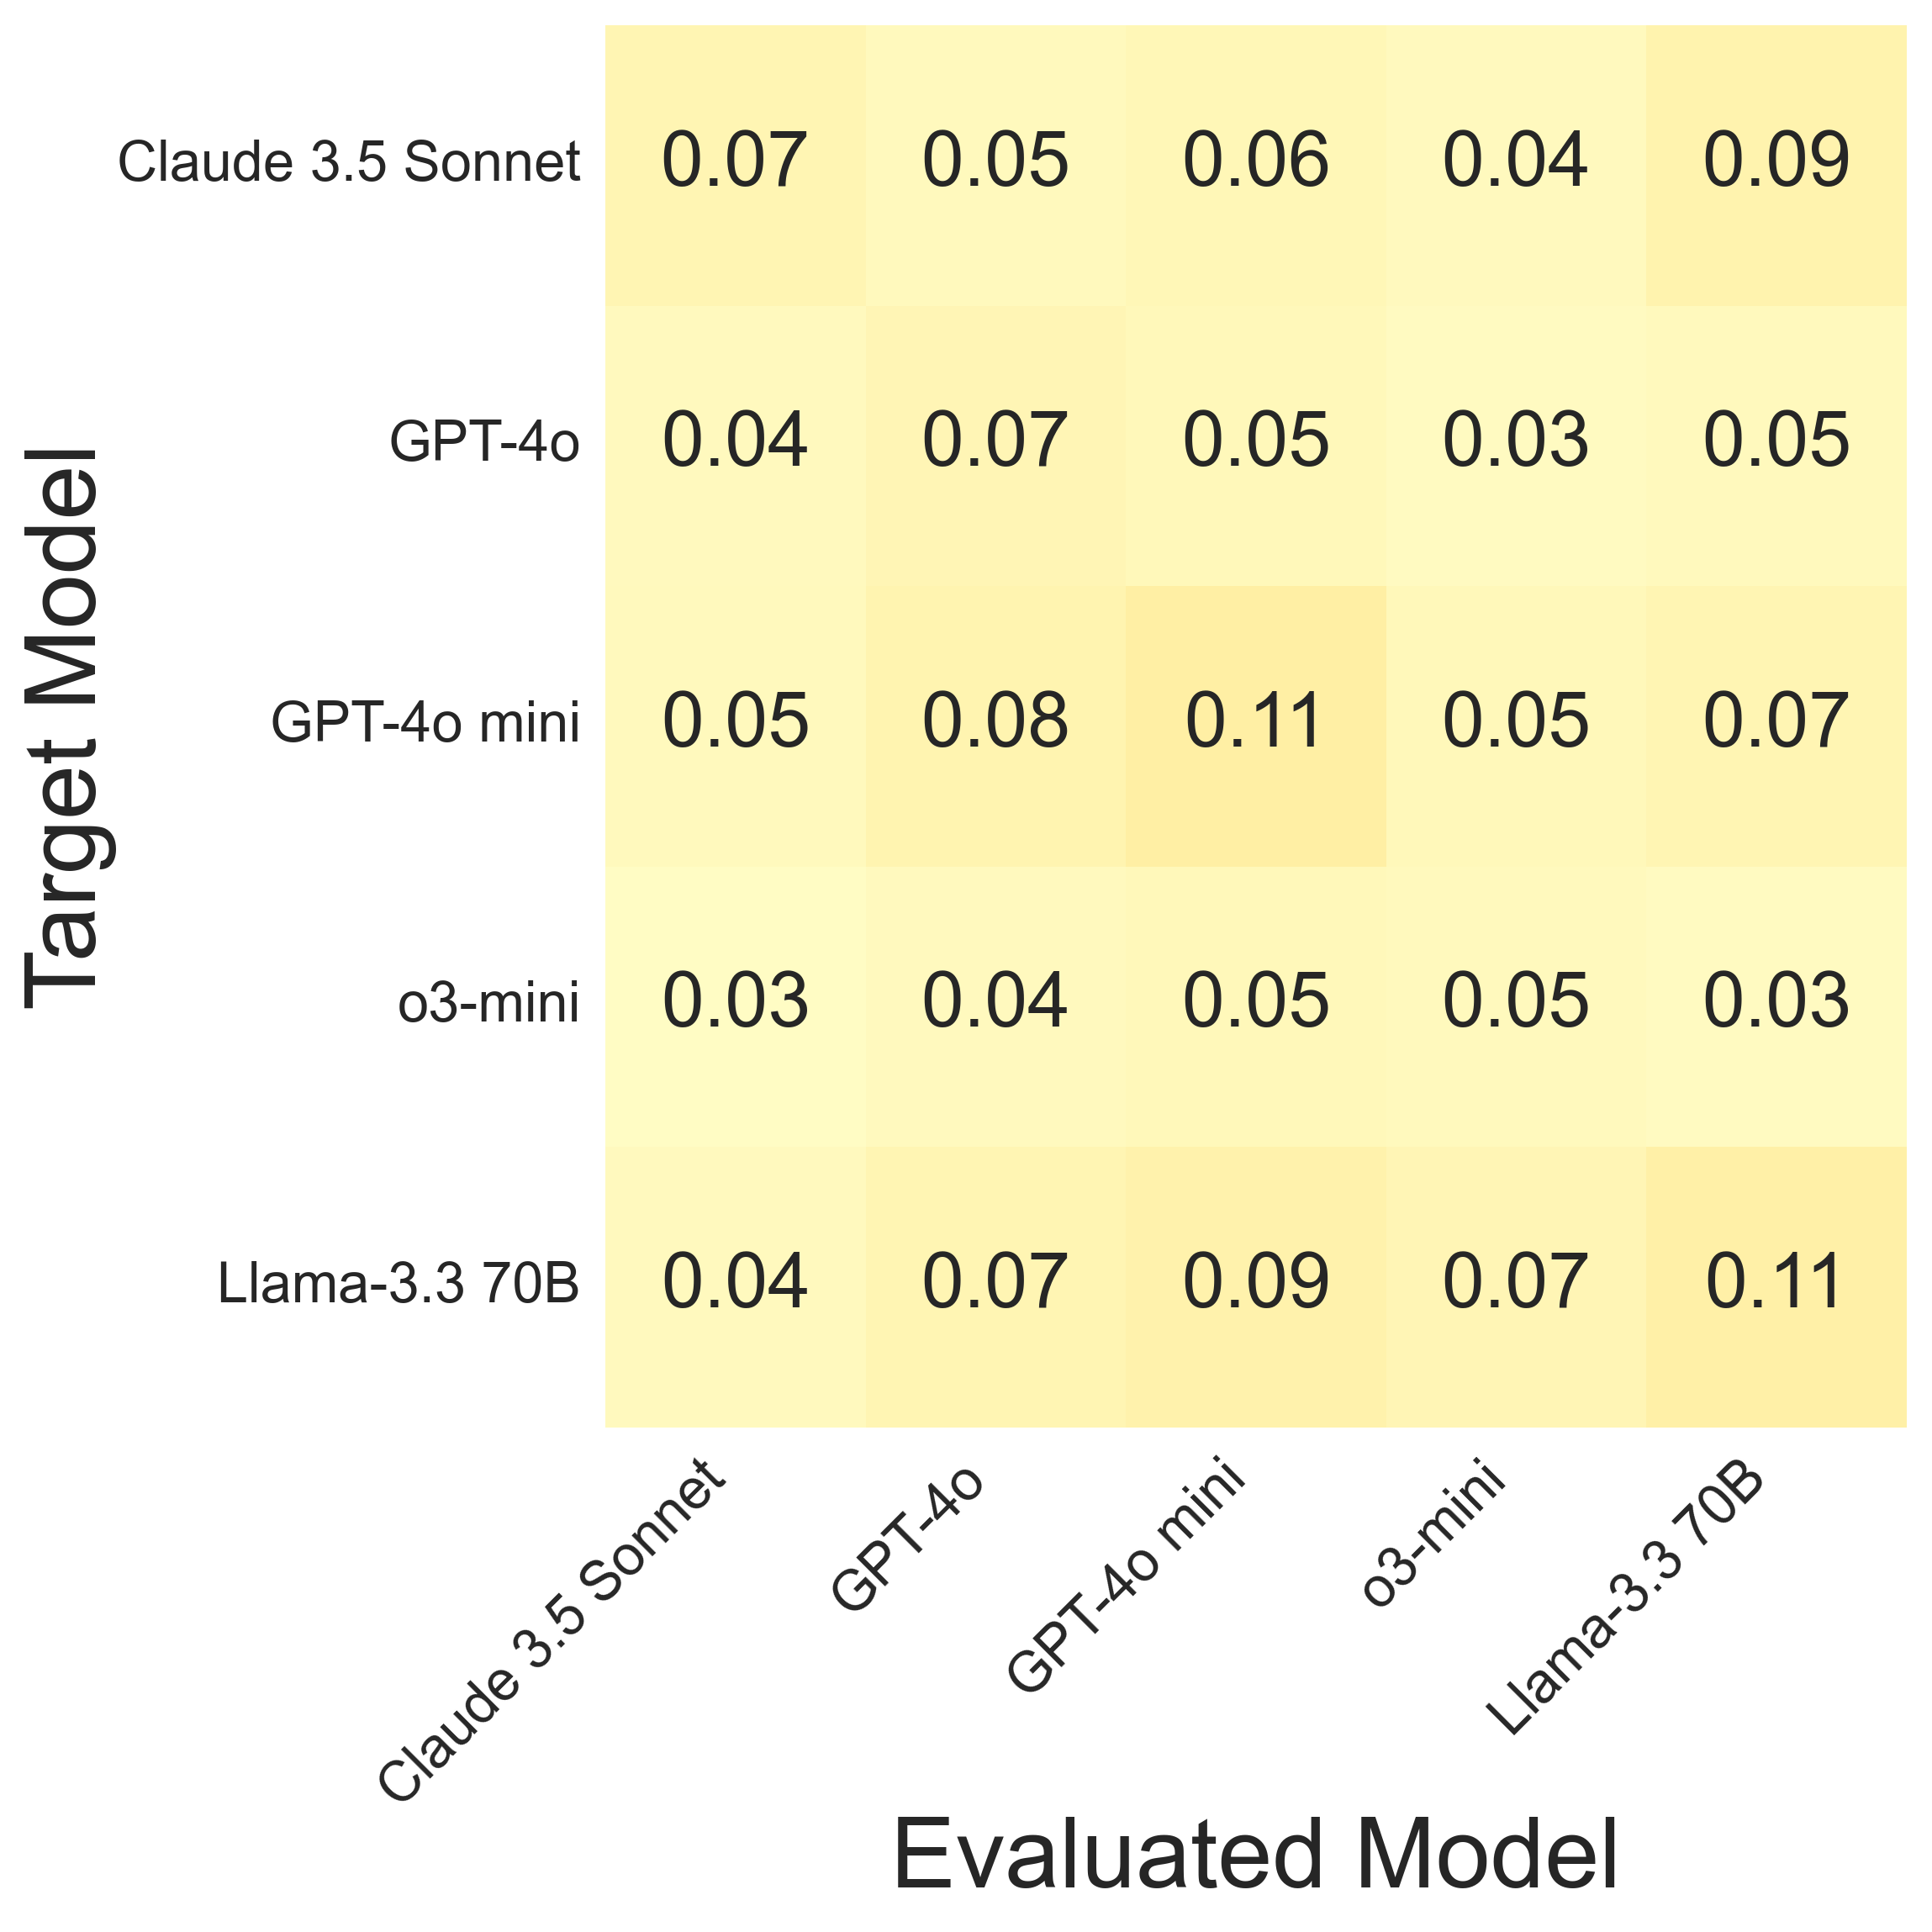

tqa_heatmap_o3_mini_nocot.pdf


In [129]:
# Create heatmaps for TruthfulQA dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get unique generator models for TruthfulQA
generator_models_tqa = df_cot_tqa['generator_model_name'].unique()

def clean_model_name_for_display(name):
    return name.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B').replace('claude-3-5-sonnet-latest', 'Claude 3.5 Sonnet').replace('gpt-4o-mini', 'GPT-4o mini').replace('gpt-4o', 'GPT-4o').replace('openai/', '').replace('anthropic/', '').replace('-latest', '').replace('-Instruct-Turbo', '').replace('-latest', '').replace('together/meta-llama/', '')

# Create a separate figure for each generator model
for idx, df_tqa in enumerate([df_cot_tqa, df_nocot_tqa]):
    for generator_model in generator_models_tqa:
        # Filter data for this generator model
        df_filtered = df_tqa[df_tqa['generator_model_name'] == generator_model]
        
        # Group by eval_model_name and re_eval_model_name
        grouped_data = df_filtered.groupby(['eval_model_name', 're_eval_model_name']).agg({
            're_eval_incorrect_count': 'sum',
            'n_datapoints': 'first'  # Get the n_datapoints value for normalization
        }).reset_index()
        
        # Normalize by the number of datapoints
        grouped_data['normalized_incorrect'] = grouped_data['re_eval_incorrect_count'] / grouped_data['n_datapoints']
        
        # Create the pivot table using the normalized values
        try:
            heatmap_data = grouped_data.pivot(
                index='eval_model_name', 
                columns='re_eval_model_name', 
                values='normalized_incorrect'
            )
            
            # Clean up model names for better display
            heatmap_data.index = [clean_model_name_for_display(name) for name in heatmap_data.index]
            heatmap_data.columns = [clean_model_name_for_display(name) for name in heatmap_data.columns]
            
            # Create the figure
            plt.figure(figsize=(8, 8), dpi=300)
            
            # Create the heatmap
            ax = sns.heatmap(
                heatmap_data,
                annot=True,
                fmt='.2f',
                cmap='YlOrRd',
                cbar=False,
                square=False,  # Allow rectangular heatmap cells
                vmin=0,
                vmax=1,
                annot_kws={'size': 22}
            )
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Set title and labels
            # plt.title(f'TruthfulQA - Generator: {clean_model_name_for_display(generator_model)}', fontsize=24, pad=20)
            plt.xlabel('Evaluated Model', fontsize=28, labelpad=0)
            plt.ylabel('Target Model', fontsize=28, labelpad=0)
            
            # Increase tick label sizes
            plt.xticks(fontsize=16, rotation=45, ha='right')
            plt.yticks(fontsize=16)
            
            plt.tight_layout()
            plt.savefig(f'tqa_heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}.pdf', dpi=300, bbox_inches='tight')
            plt.show()
        except ValueError as e:
            print(f"Error creating heatmap for {generator_model}: {e}")
            
print(f'tqa_heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}_{"cot" if idx == 0 else "nocot"}.pdf')

Cached data to cached_politeness_GPT_4o_cot.csv
Saved plot to politeness_heatmap_GPT_4o_cot.pdf


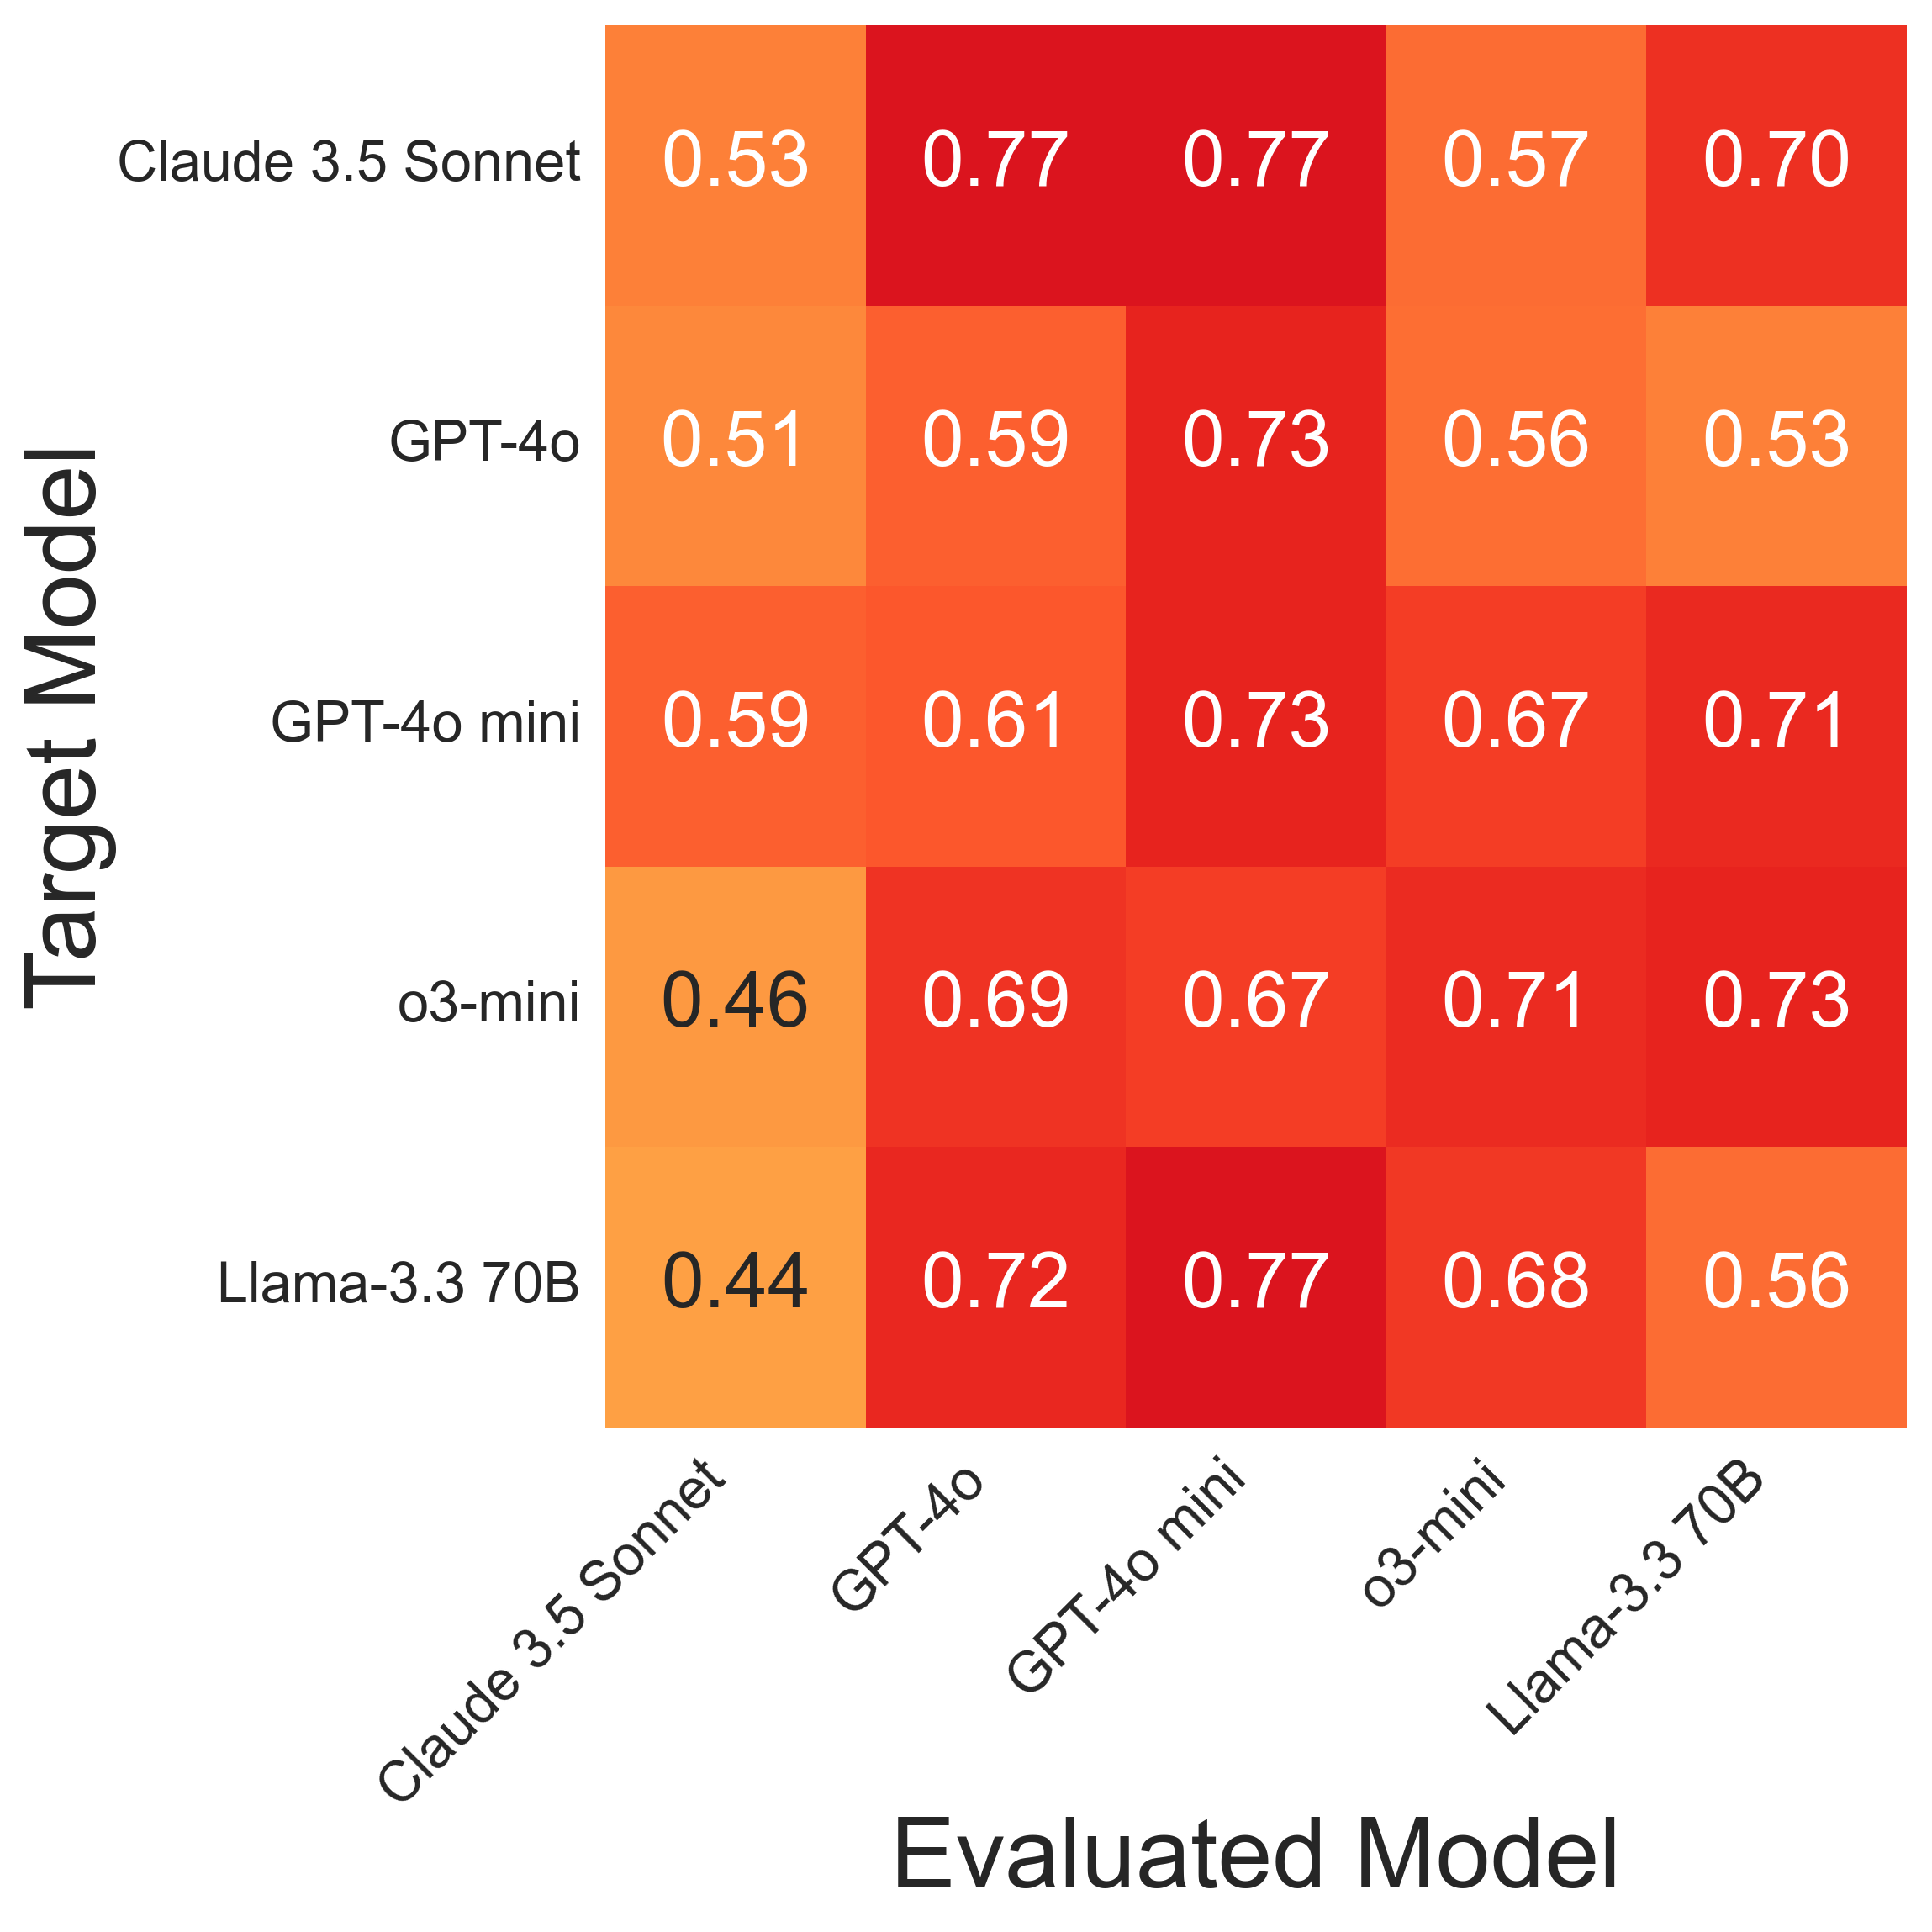

Cached data to cached_politeness_o3_mini_cot.csv
Saved plot to politeness_heatmap_o3_mini_cot.pdf


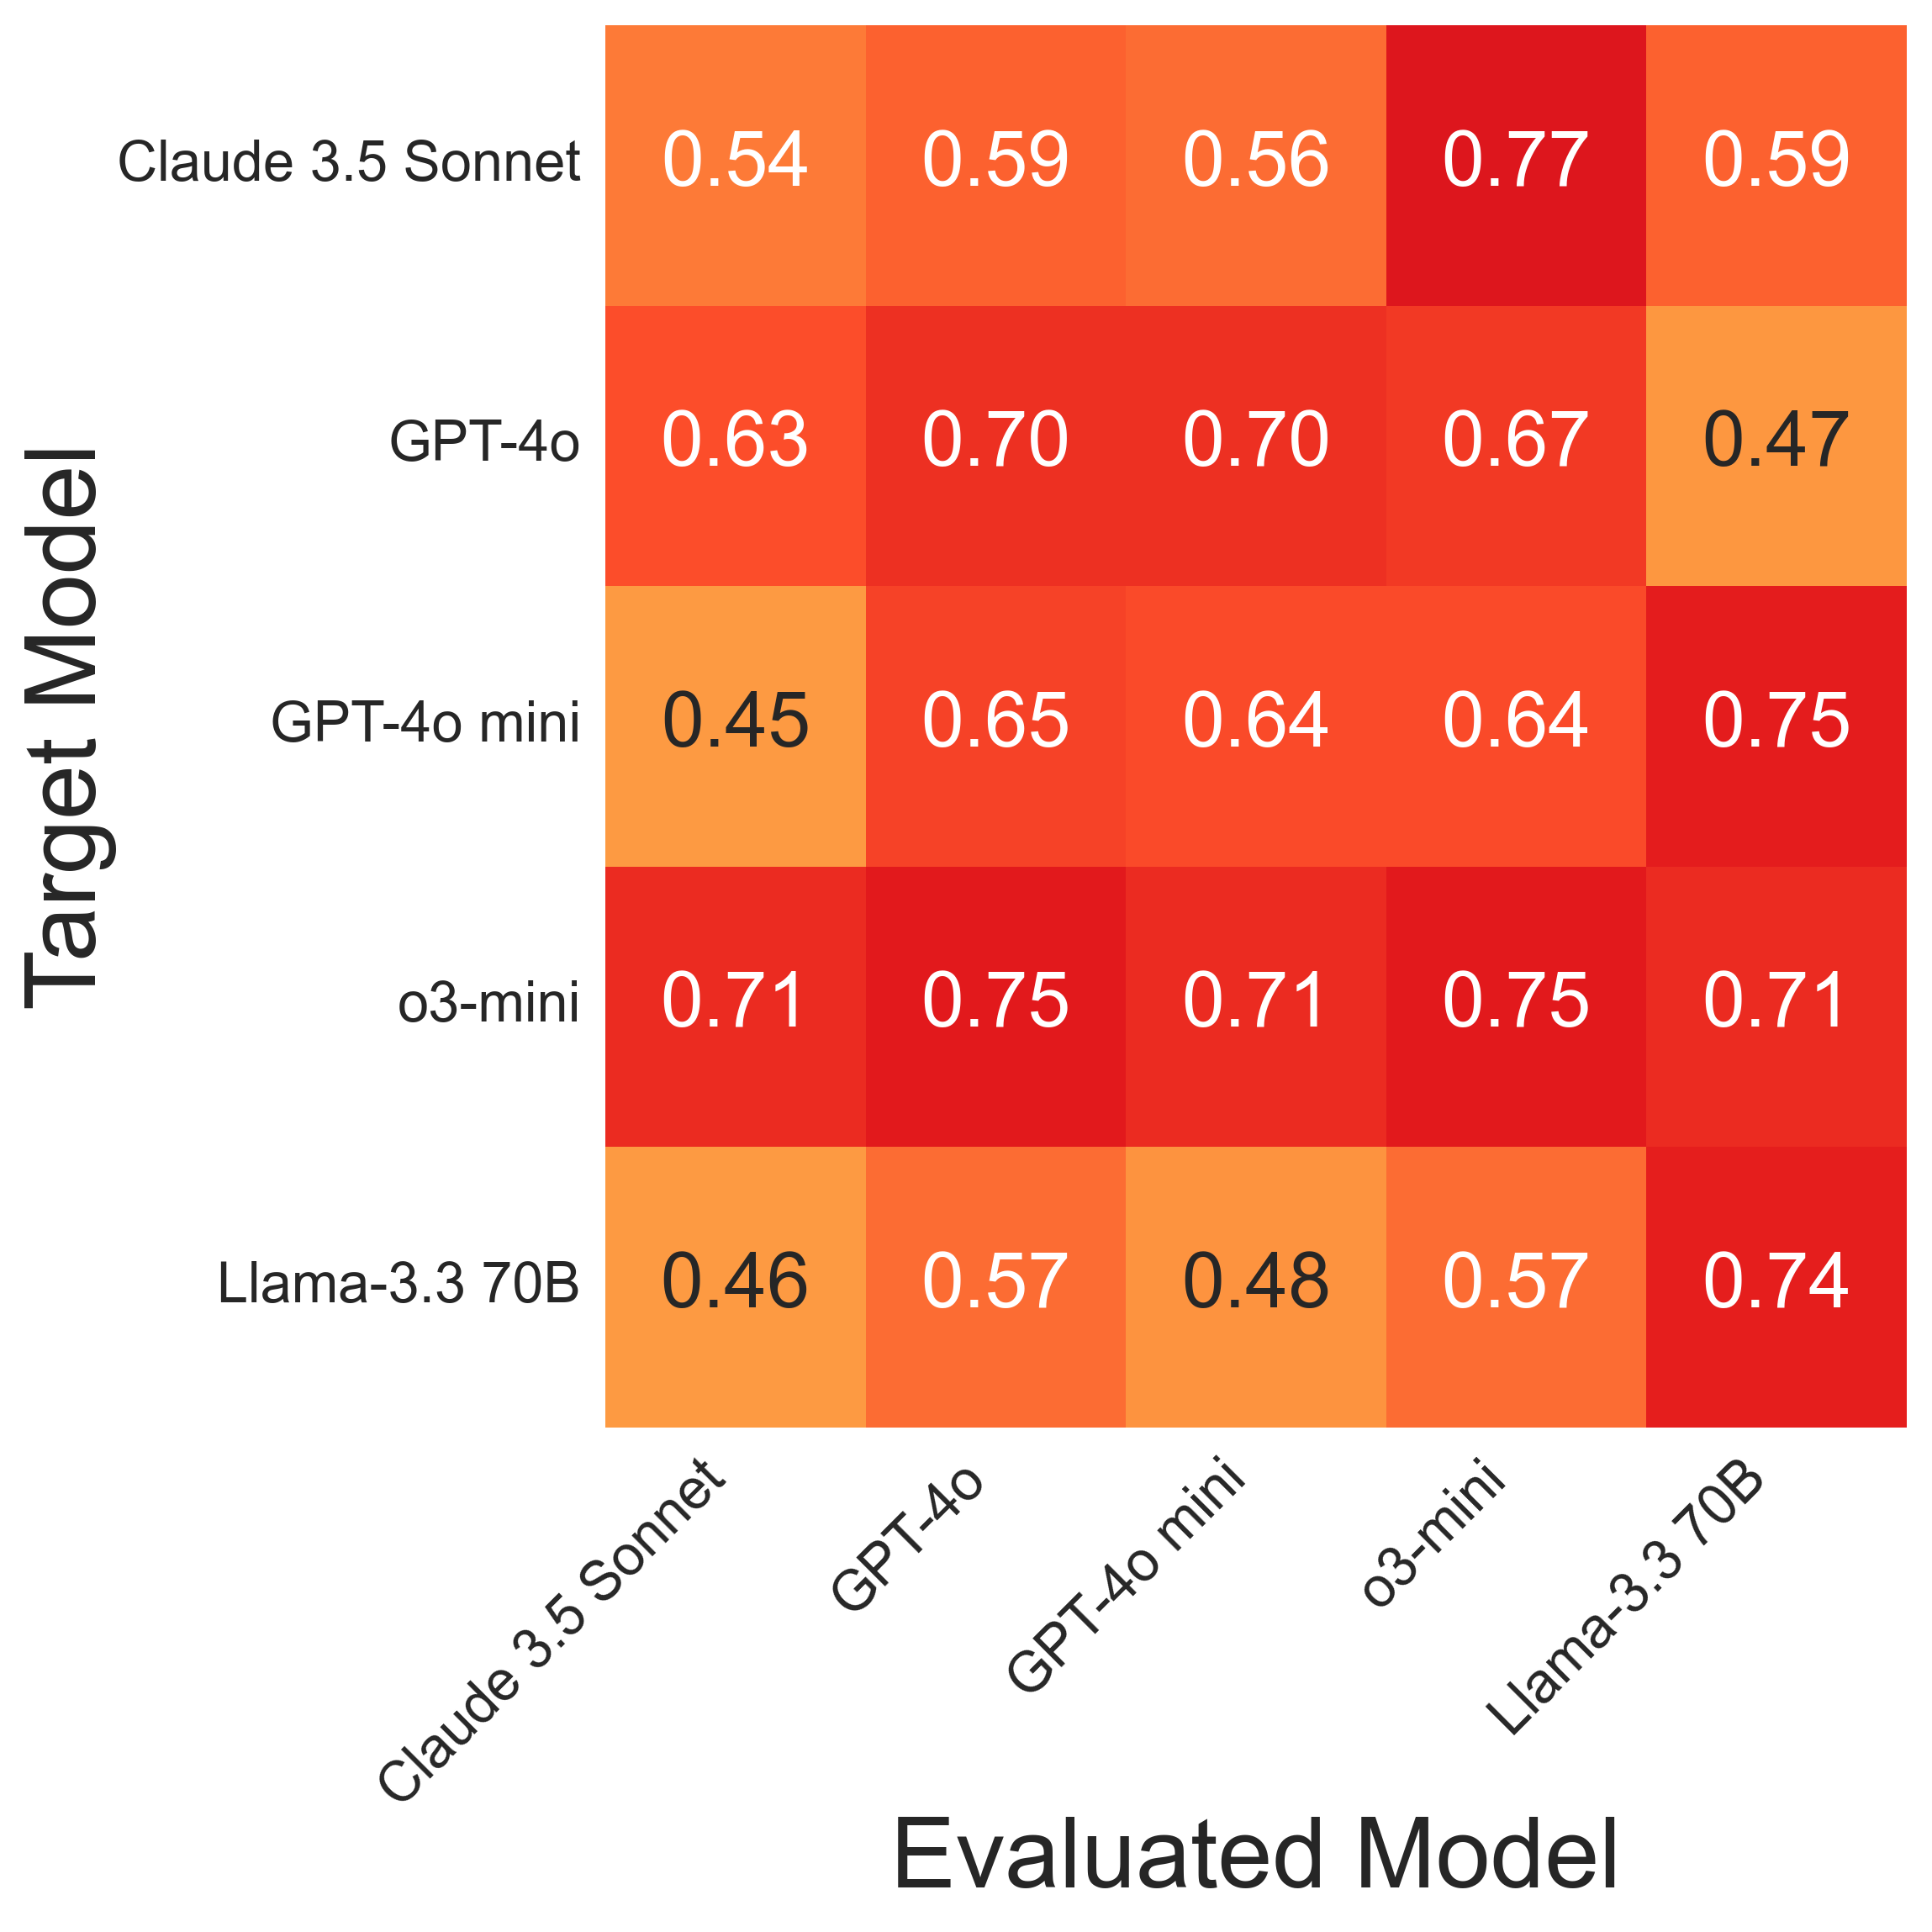

Cached data to cached_politeness_GPT_4o_nocot.csv
Saved plot to politeness_heatmap_GPT_4o_nocot.pdf


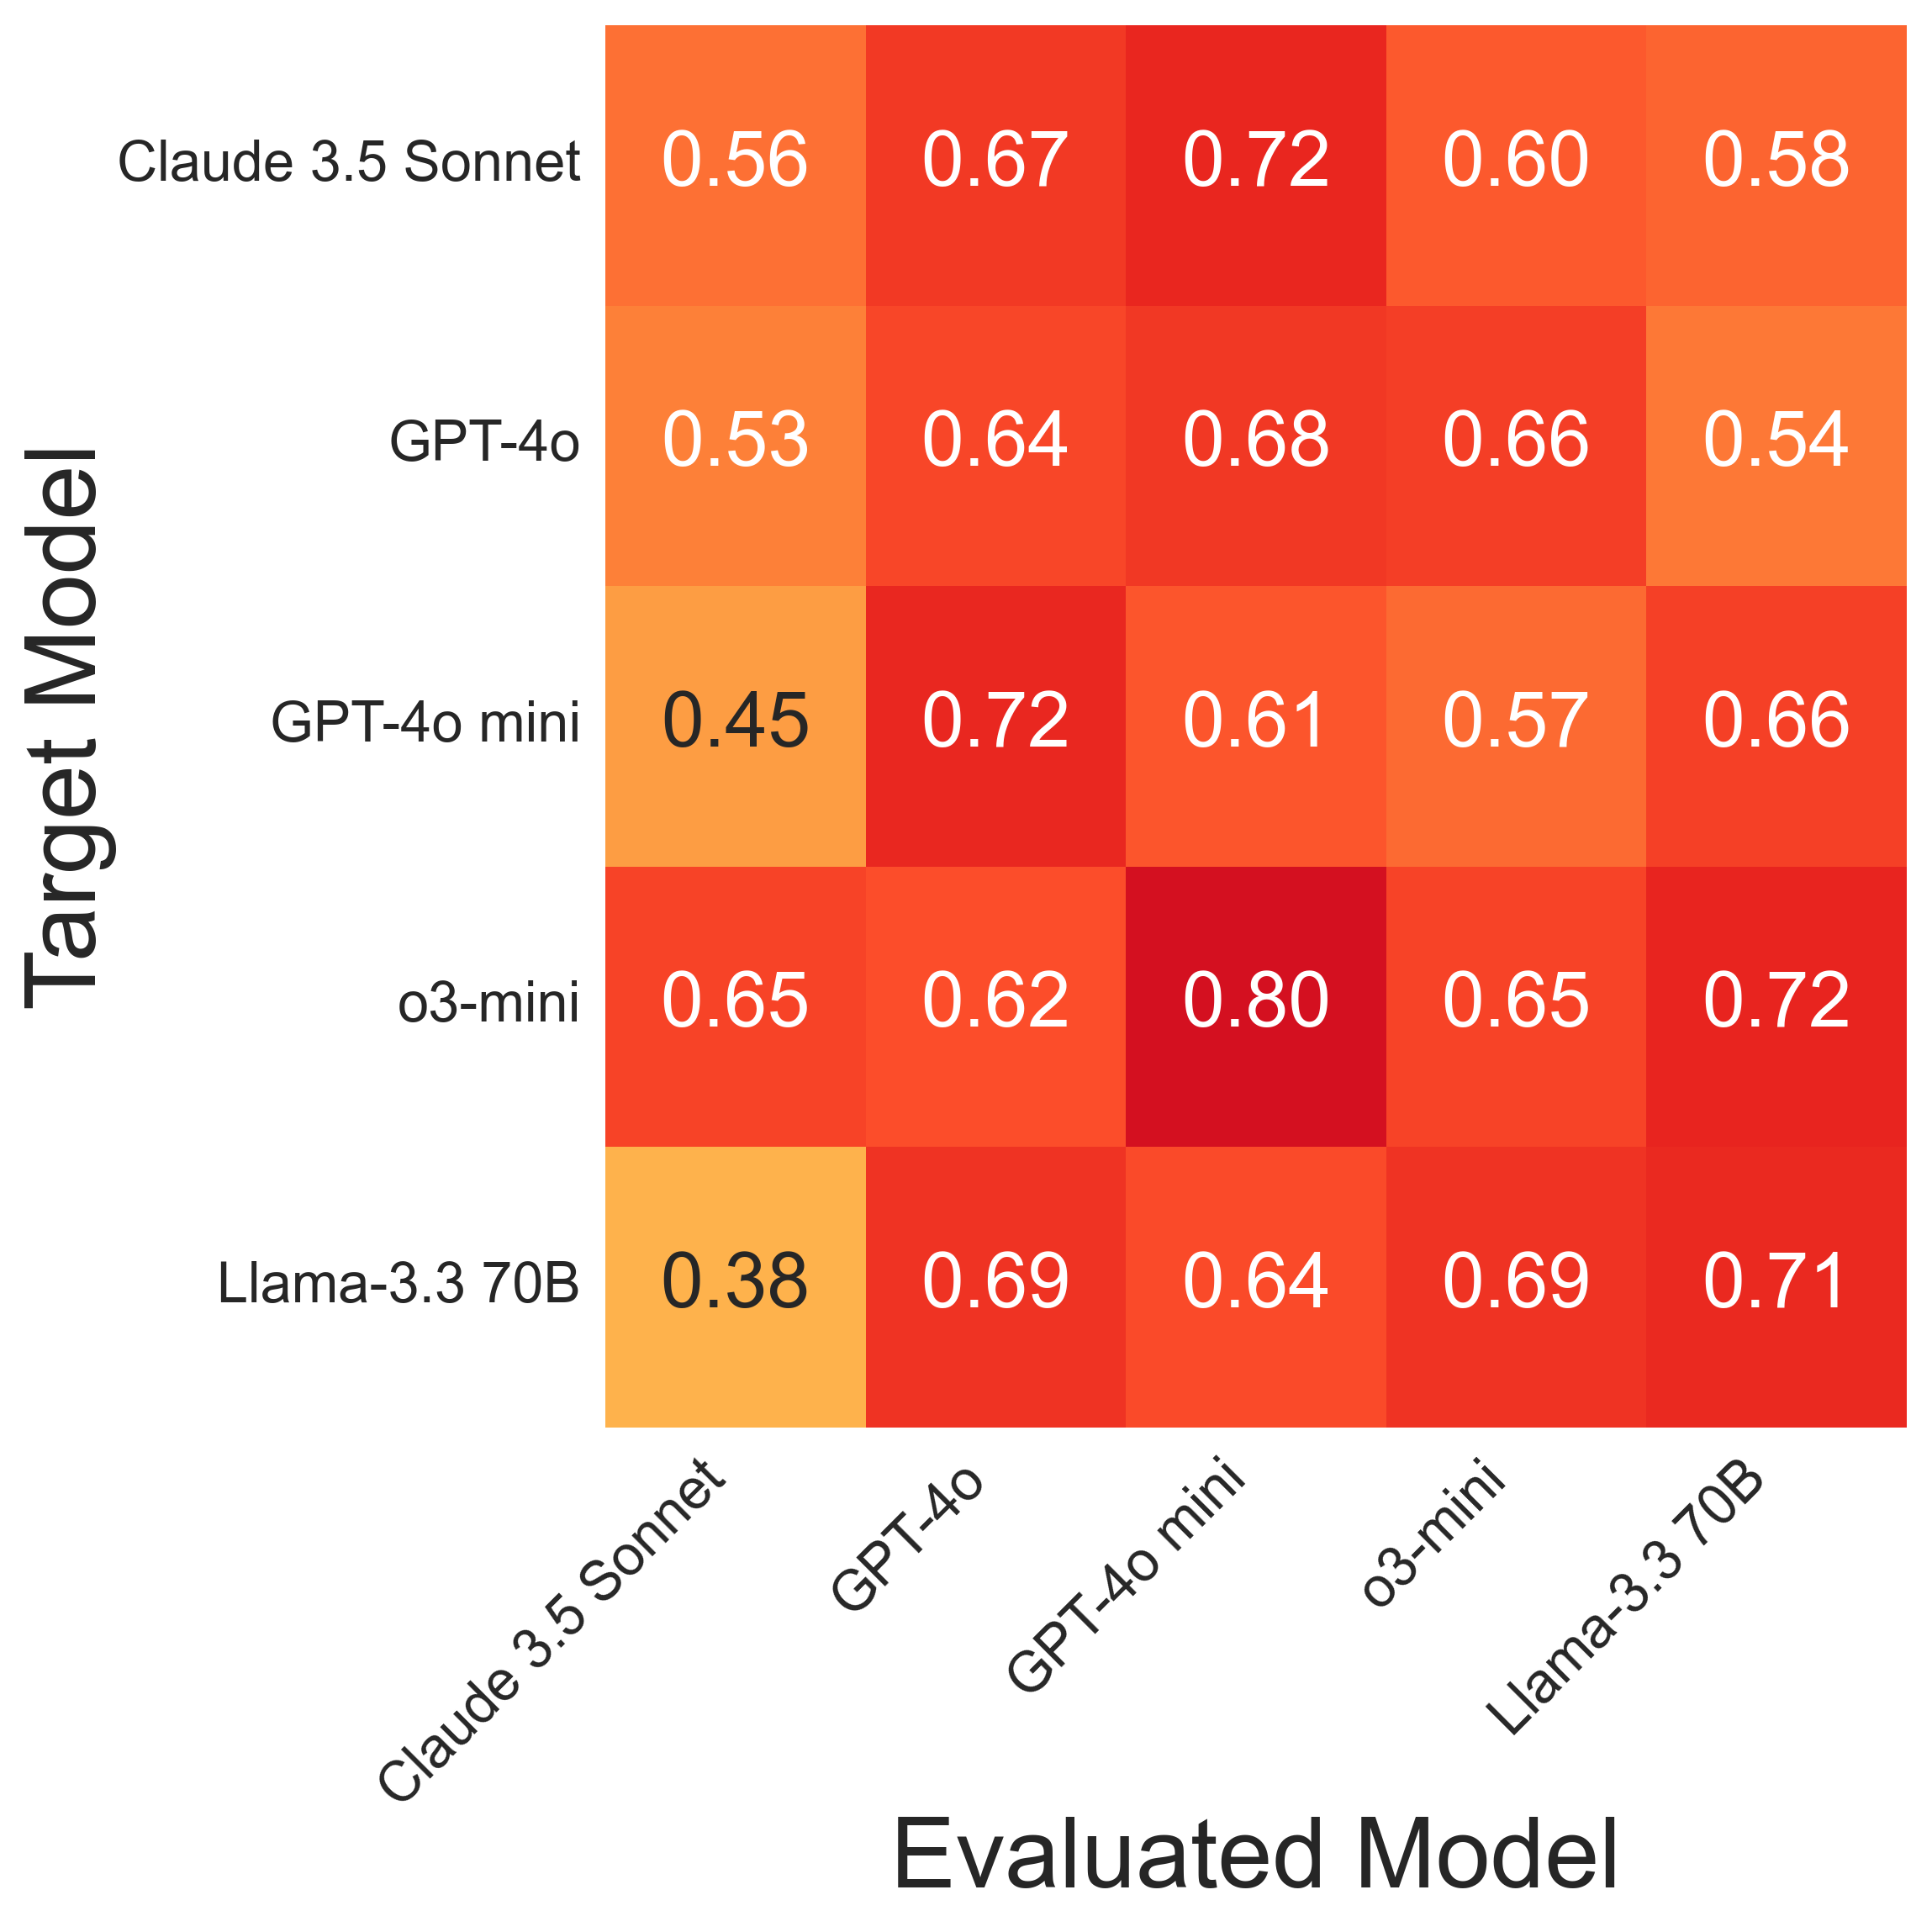

Cached data to cached_politeness_o3_mini_nocot.csv
Saved plot to politeness_heatmap_o3_mini_nocot.pdf


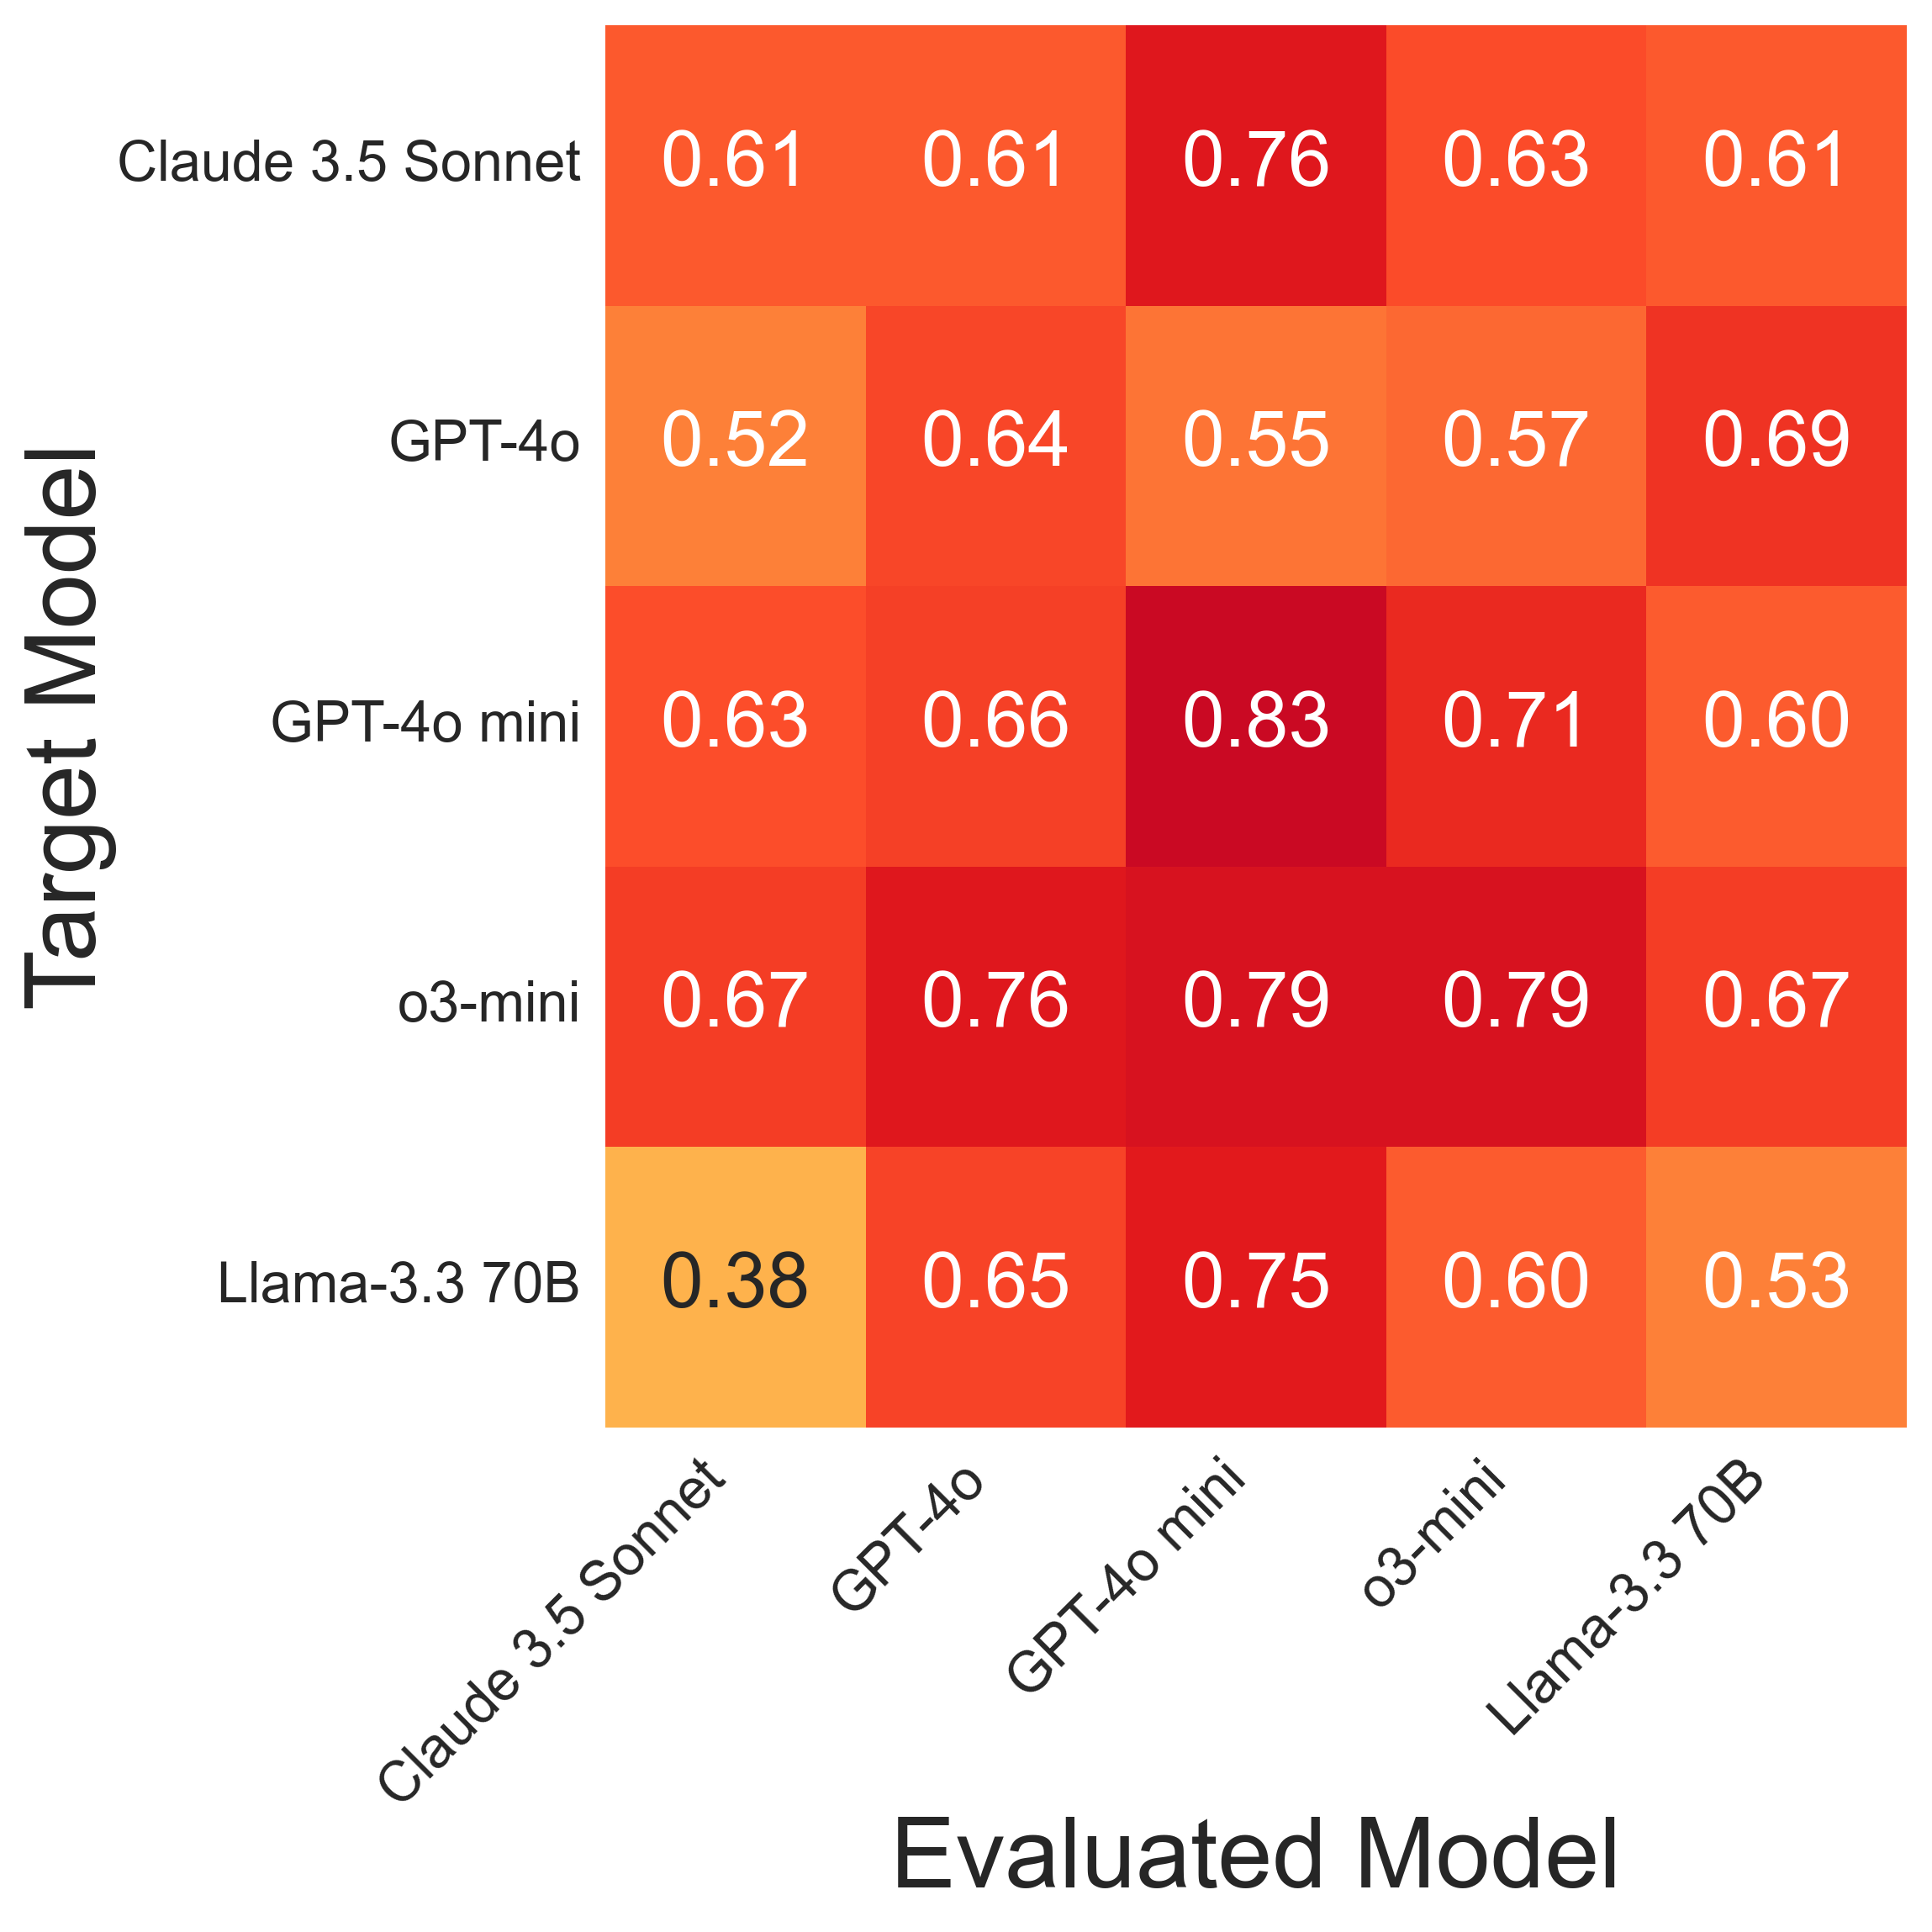


To use cached data in the future, you can use this code:

# Load cached data
cached_files = [f for f in os.listdir('.') if f.startswith('cached_politeness_')]
for cache_file in cached_files:
    # Extract generator model and dataset type from filename
    parts = cache_file.replace('cached_politeness_', '').replace('.csv', '').split('_')
    generator_model = '_'.join(parts[:-1])  # Last part is 'cot' or 'nocot'
    dataset_type = parts[-1]
    
    # Load the data
    heatmap_df = pd.read_csv(cache_file)
    
    # Create pivot table and plot
    # ... plotting code here ...



In [130]:
# Create heatmaps for the Politeness dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def clean_model_name_for_display(name):
    return name.replace('Llama-3.3-70B-Instruct-Turbo', 'Llama-3.3 70B').replace('claude-3-5-sonnet-latest', 'Claude 3.5 Sonnet').replace('gpt-4o-mini', 'GPT-4o mini').replace('gpt-4o', 'GPT-4o').replace('openai/', '').replace('anthropic/', '').replace('-latest', '').replace('-Instruct-Turbo', '').replace('-latest', '').replace('together/meta-llama/', '')

# Process and cache data for both CoT and no-CoT
datasets = [
    {"df": df_cot_politeness, "name": "cot"},
    {"df": df_nocot_politeness, "name": "nocot"}
]

for dataset in datasets:
    df = dataset["df"]
    dataset_name = dataset["name"]
    generator_models = df['generator_model'].unique()
    eval_models = df['eval_model'].unique()
    
    # For each generator model, process and cache data
    for generator_model in generator_models:
        # Create a dataframe to hold all the values
        heatmap_data_list = []
        
        # Loop through all eval model and re-eval model combinations
        for eval_model in eval_models:
            for re_eval_model in eval_models:
                try:
                    # Find the log path for this combination
                    filtered_df = df[
                        (df['generator_model'] == generator_model) & 
                        (df['eval_model'] == eval_model) & 
                        (df['re_eval_model'] == re_eval_model)
                    ]
                    
                    if len(filtered_df) > 0 :
                        # Try to get a valid log path, starting from the end and working backwards
                        log_path = None
                        for idx in range(-1, -len(filtered_df)-1, -1):
                            try:
                                path = filtered_df.re_eval_log_path.values[idx]
                                if isinstance(path, str):  # Check if it's a string and not NaN
                                    log_path = make_log_path_relative(path)
                                    break
                            except (AttributeError, IndexError):
                                pass
                        
                        # If we couldn't find a valid log path, set to 0
                        if log_path is None:
                            raise FileNotFoundError("No valid log path found")
                        log = read_eval_log(log_path)
                        
                        # Extract the error rate and normalize
                        normalized_incorrect = (1 - log.results.scores[-1].metrics['accuracy'].value)
                        
                        # Add to our data list
                        heatmap_data_list.append({
                            'eval_model': eval_model,
                            're_eval_model': re_eval_model,
                            'normalized_incorrect': normalized_incorrect
                        })
                except (IndexError, KeyError, FileNotFoundError) as e:
                    print(f"Error processing {eval_model} evaluated by {re_eval_model}: {e}")
                    # Skip this combination if there's an error
                    continue
        
        # Convert list to DataFrame
        if not heatmap_data_list:
            print(f"No data found for generator model {generator_model} ({dataset_name})")
            continue
            
        heatmap_df = pd.DataFrame(heatmap_data_list)
        
        # Cache the processed data to CSV
        cache_filename = f'cached_politeness_{clean_model_name_for_display(generator_model).replace("-", "_")}_{dataset_name}.csv'
        heatmap_df.to_csv(cache_filename, index=False)
        print(f"Cached data to {cache_filename}")
        
        try:
            # Create the pivot table
            heatmap_pivot = heatmap_df.pivot(
                index='eval_model',
                columns='re_eval_model',
                values='normalized_incorrect'
            )
            
            # Clean up model names for better display
            heatmap_pivot.index = [clean_model_name_for_display(name) for name in heatmap_pivot.index]
            heatmap_pivot.columns = [clean_model_name_for_display(name) for name in heatmap_pivot.columns]
            
            # Create the figure
            plt.figure(figsize=(8, 8), dpi=300)
            
            # Create the heatmap
            ax = sns.heatmap(
                heatmap_pivot,
                annot=True,
                fmt='.2f',
                cmap='YlOrRd',
                cbar=False,
                square=False,
                vmin=0,
                vmax=1,
                annot_kws={'size': 22}
            )
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Set title and labels
            cot_label = "CoT" if dataset_name == "cot" else "No-CoT"
            # plt.title(f'Politeness ({cot_label}) - Generator: {clean_model_name_for_display(generator_model)}', fontsize=24, pad=20)
            plt.xlabel('Evaluated Model', fontsize=28, labelpad=0)
            plt.ylabel('Target Model', fontsize=28, labelpad=0)
            
            # Increase tick label sizes
            plt.xticks(fontsize=16, rotation=45, ha='right')
            plt.yticks(fontsize=16)
            
            plt.tight_layout()
            output_filename = f'politeness_heatmap_{clean_model_name_for_display(generator_model).replace("-", "_")}_{dataset_name}.pdf'
            plt.savefig(output_filename, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {output_filename}")
            plt.show()
            
        except ValueError as e:
            print(f"Error creating heatmap for {generator_model} ({dataset_name}): {e}")

# Example code for loading from cache instead of processing logs again
print("\nTo use cached data in the future, you can use this code:")
print("""
# Load cached data
cached_files = [f for f in os.listdir('.') if f.startswith('cached_politeness_')]
for cache_file in cached_files:
    # Extract generator model and dataset type from filename
    parts = cache_file.replace('cached_politeness_', '').replace('.csv', '').split('_')
    generator_model = '_'.join(parts[:-1])  # Last part is 'cot' or 'nocot'
    dataset_type = parts[-1]
    
    # Load the data
    heatmap_df = pd.read_csv(cache_file)
    
    # Create pivot table and plot
    # ... plotting code here ...
""")